# Agentic Architecture Research for Scientific Tasks

This notebook evaluates LangGraph-based agent architectures on two API-backed scientific domains:

1. Materials informatics with Materials Project.
2. Cheminformatics with PubChem and ChEMBL.

Each domain includes one easy retrieval task and one hard multi-hop task:

- Materials: dimensional polymorph discovery using Materials Project summary data and Robocrystallographer descriptions.
- Cheminformatics: EGFR selectivity screening using ChEMBL target, activity, and molecule endpoints.

Scores are rule-grounded and deterministic. LLM agents plan, critique, and write memory lessons; they do not determine the final metric.


In [ ]:
%pip install -r requirements.txt

In [ ]:
import os, json, time, math
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, TypedDict
from urllib.parse import quote

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv(dotenv_path=".env", override=False)

MP_API_KEY    = os.environ.get("MATERIALS_API_KEY", "")
API_ENDPOINT  = os.environ.get("API_ENDPOINT", "http://mobydick.elte-dh.hu:23432/v1")
ELTE_API_KEY  = os.environ.get("ELTE_API_KEY")
MODEL_NAME    = os.environ.get("MODEL_NAME", "gpt-4o-mini")

PUBCHEM_BASE_URL = os.environ.get("PUBCHEM_BASE_URL", "https://pubchem.ncbi.nlm.nih.gov/rest/pug").rstrip("/")
CHEMBL_BASE_URL  = os.environ.get("CHEMBL_BASE_URL", "https://www.ebi.ac.uk/chembl/api/data").rstrip("/")
PUBLIC_API_TIMEOUT_SECONDS = int(os.environ.get("PUBLIC_API_TIMEOUT_SECONDS", "60"))
PUBLIC_API_MAX_RETRIES = int(os.environ.get("PUBLIC_API_MAX_RETRIES", "2"))
VALIDATE_PUBLIC_APIS = os.environ.get("VALIDATE_PUBLIC_APIS", "true").lower() == "true"

N_RUNS = 2
LLM_REQUEST_TIMEOUT_SECONDS = int(os.environ.get("LLM_REQUEST_TIMEOUT_SECONDS", "1200"))
LLM_MAX_RETRIES = int(os.environ.get("LLM_MAX_RETRIES", "1"))
LLM_MAX_TOKENS_HEALTHCHECK = int(os.environ.get("LLM_MAX_TOKENS_HEALTHCHECK", "1024"))
LLM_MAX_TOKENS_PLANNING = int(os.environ.get("LLM_MAX_TOKENS_PLANNING", "4096"))
MAX_REVISIONS = int(os.environ.get("MAX_REVISIONS", "1"))
DISABLE_QWEN_THINKING = os.environ.get("DISABLE_QWEN_THINKING", "true").lower() == "true"
RUN_SMOKE_TEST = os.environ.get("RUN_SMOKE_TEST", "false").lower() == "true"

PROJECT_ROOT = Path(".").resolve()


def validate_execution_environment():
    """Fail-fast check for all external backends before running the experiment matrix."""
    issues = []
    if not MP_API_KEY:
        issues.append("MATERIALS_API_KEY / MP_API_KEY is not configured.")
    if not ELTE_API_KEY:
        issues.append("ELTE_API_KEY is not configured.")
    if not API_ENDPOINT:
        issues.append("API_ENDPOINT is not configured.")
    if not MODEL_NAME:
        issues.append("MODEL_NAME is not configured.")

    if VALIDATE_PUBLIC_APIS:
        try:
            _ = http_get_json(f"{CHEMBL_BASE_URL}/status.json", timeout=PUBLIC_API_TIMEOUT_SECONDS)
        except Exception as exc:
            issues.append(f"ChEMBL API status check failed: {repr(exc)}")
        try:
            _ = pubchem_get_properties("aspirin", ["MolecularFormula", "MolecularWeight", "CanonicalSMILES"])
        except Exception as exc:
            issues.append(f"PubChem aspirin property check failed: {repr(exc)}")

    if issues:
        raise RuntimeError(
            "Execution environment validation failed. Fix the following before running the experiment:\n"
            + "\n".join(f"  - {x}" for x in issues)
        )
    print("Execution environment validation passed.")
    return True


print("MODEL_NAME:", MODEL_NAME)
print("API_ENDPOINT configured:", API_ENDPOINT)
print("ELTE_API_KEY configured:", bool(ELTE_API_KEY))
print("MATERIALS_API_KEY configured:", bool(MP_API_KEY))
print("N_RUNS:", N_RUNS)
print("PUBCHEM_BASE_URL:", PUBCHEM_BASE_URL)
print("CHEMBL_BASE_URL:", CHEMBL_BASE_URL)
print("VALIDATE_PUBLIC_APIS:", VALIDATE_PUBLIC_APIS)
print("LLM_REQUEST_TIMEOUT_SECONDS:", LLM_REQUEST_TIMEOUT_SECONDS)
print("LLM_MAX_TOKENS_PLANNING:", LLM_MAX_TOKENS_PLANNING)
print("MAX_REVISIONS:", MAX_REVISIONS)
print("DISABLE_QWEN_THINKING:", DISABLE_QWEN_THINKING)


In [3]:
try:
    from langgraph.graph import StateGraph, END
    from openai import OpenAI
    LANGGRAPH_AVAILABLE = True
except Exception as exc:
    print("LangGraph/OpenAI import failed:", repr(exc))
    LANGGRAPH_AVAILABLE = False
    StateGraph = None
    END = "__end__"
    OpenAI = None


def make_openai_client() -> Optional[Any]:
    """OpenAI-compatible client used for JSON Schema structured outputs."""
    if not (OpenAI and ELTE_API_KEY and API_ENDPOINT):
        return None
    return OpenAI(
        api_key=ELTE_API_KEY,
        base_url=API_ENDPOINT,
        timeout=LLM_REQUEST_TIMEOUT_SECONDS,
        max_retries=LLM_MAX_RETRIES,
    )

OPENAI_CLIENT = make_openai_client()
print("OpenAI-compatible client available:", OPENAI_CLIENT is not None)


In [ ]:
import requests
import json
import time
import random
import pprint

TEST_JSON_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "ok": {"type": "boolean"}
    },
    "required": ["ok"],
}


def _is_retryable_connection_error(exc: Exception) -> bool:
    """Detect endpoint/network failures that may succeed after retry."""
    text = repr(exc).lower()
    markers = [
        "timeout", "timed out", "apitimeouterror", "readtimeout", "connecttimeout",
        "apiconnectionerror", "connection error", "connection reset", "connection reset by peer",
        "readerror", "connecterror", "connection refused", "remoteprotocolerror",
        "server disconnected", "protocolerror", "temporarily unavailable", "502", "503", "504",
    ]
    return any(marker in text for marker in markers)


def list_available_models():
    """Query the OpenAI-compatible /models endpoint and return available model IDs."""
    if not API_ENDPOINT:
        raise RuntimeError("API_ENDPOINT is not configured, so I cannot list models.")
    if not ELTE_API_KEY:
        raise RuntimeError("ELTE_API_KEY is not configured, so I cannot list models.")

    base_url = API_ENDPOINT.rstrip("/")
    models_url = f"{base_url}/models"
    headers = {"Authorization": f"Bearer {ELTE_API_KEY}", "Accept": "application/json"}

    response = requests.get(models_url, headers=headers, timeout=30)
    response.raise_for_status()
    payload = response.json()
    raw_models = payload.get("data", [])

    model_ids = []
    for item in raw_models:
        if isinstance(item, dict) and "id" in item:
            model_ids.append(item["id"])
        elif isinstance(item, str):
            model_ids.append(item)
    return sorted(model_ids)


def _object_to_plain_dict(obj):
    """Convert OpenAI SDK / pydantic / dict-like objects to a plain Python dict."""
    if obj is None:
        return {}
    if isinstance(obj, dict):
        return obj
    if hasattr(obj, "model_dump"):
        return obj.model_dump()
    if hasattr(obj, "dict"):
        return obj.dict()
    try:
        return dict(obj)
    except Exception:
        pass
    out = {}
    for key in dir(obj):
        if key.startswith("_"):
            continue
        try:
            value = getattr(obj, key)
        except Exception:
            continue
        if not callable(value):
            out[key] = value
    return out


def _extract_usage_from_response(response):
    """Extract actual token usage from an OpenAI-compatible chat completion response."""
    usage_obj = getattr(response, "usage", None)
    if usage_obj is None:
        response_dict = _object_to_plain_dict(response)
        usage_obj = response_dict.get("usage")

    usage = _object_to_plain_dict(usage_obj)
    prompt_tokens = usage.get("prompt_tokens")
    completion_tokens = usage.get("completion_tokens")
    total_tokens = usage.get("total_tokens")

    completion_details = usage.get("completion_tokens_details") or {}
    prompt_details = usage.get("prompt_tokens_details") or {}
    if not isinstance(completion_details, dict):
        completion_details = _object_to_plain_dict(completion_details)
    if not isinstance(prompt_details, dict):
        prompt_details = _object_to_plain_dict(prompt_details)

    reasoning_tokens = (
        completion_details.get("reasoning_tokens")
        or usage.get("reasoning_tokens")
        or 0
    )
    cached_prompt_tokens = (
        prompt_details.get("cached_tokens")
        or usage.get("cached_tokens")
        or 0
    )

    actual_available = any(
        value is not None for value in [prompt_tokens, completion_tokens, total_tokens]
    )

    return {
        "actual_usage_available": bool(actual_available),
        "actual_prompt_tokens": int(prompt_tokens) if prompt_tokens is not None else None,
        "actual_completion_tokens": int(completion_tokens) if completion_tokens is not None else None,
        "actual_total_tokens": int(total_tokens) if total_tokens is not None else None,
        "actual_reasoning_tokens": int(reasoning_tokens or 0),
        "actual_cached_prompt_tokens": int(cached_prompt_tokens or 0),
        "raw_usage": usage,
    }

def _response_to_dict(response):
    """Convert OpenAI SDK response object to a plain dict for debugging."""
    return _object_to_plain_dict(response)


def _extract_json_from_response(response, *, debug=False):
    """
    Extract JSON from common OpenAI-compatible response shapes.

    Handles:
    - message.content as JSON string
    - message.parsed if provided
    - message.content as list of content parts
    - diagnostic reasoning-only responses from some Qwen/vLLM endpoints
    """
    choice = response.choices[0]
    message = choice.message

    if debug:
        print("\n=== RAW RESPONSE DIAGNOSTIC ===")
        pprint.pp(_response_to_dict(response))
        print("=== END RAW RESPONSE DIAGNOSTIC ===\n")

    parsed = getattr(message, "parsed", None)
    if parsed is not None:
        return parsed

    content = getattr(message, "content", None)

    if isinstance(content, list):
        text_parts = []
        for part in content:
            if isinstance(part, dict):
                if part.get("type") == "text" and "text" in part:
                    text_parts.append(part["text"])
                elif "text" in part:
                    text_parts.append(part["text"])
            elif isinstance(part, str):
                text_parts.append(part)
        content = "".join(text_parts)

    if isinstance(content, str) and content.strip():
        return json.loads(content)

    finish_reason = getattr(choice, "finish_reason", None)
    refusal = getattr(message, "refusal", None)
    tool_calls = getattr(message, "tool_calls", None)
    reasoning = getattr(message, "reasoning", None)

    if finish_reason == "length" and reasoning and not content:
        raise ValueError(
            "The model used the completion budget for reasoning and produced no final JSON content. "
            "Increase LLM_MAX_TOKENS_* or set DISABLE_QWEN_THINKING=true."
        )

    raise ValueError(
        "The model returned empty message content.\n"
        f"finish_reason={finish_reason}\n"
        f"reasoning_present={bool(reasoning)}\n"
        f"refusal={refusal}\n"
        f"tool_calls={tool_calls}\n"
        "Set debug=True in _chat_completion_json_schema(...) to inspect the full response."
    )


def _with_no_think_prefix(messages):
    """Add a Qwen-compatible no-thinking hint without changing the JSON schema."""
    if not DISABLE_QWEN_THINKING:
        return messages
    out = [dict(m) for m in messages]
    # Add /no_think to the final user turn; many Qwen chat templates understand this.
    for i in range(len(out) - 1, -1, -1):
        if out[i].get("role") == "user":
            content = str(out[i].get("content", ""))
            if "/no_think" not in content[:50]:
                out[i]["content"] = "/no_think\n" + content
            break
    return out


def _chat_completion_json_schema(messages, schema, schema_name, max_tokens=None, debug=False):
    """One OpenAI-compatible chat-completion call using strict JSON Schema."""
    if OPENAI_CLIENT is None:
        raise RuntimeError("OPENAI_CLIENT is None. Check API_ENDPOINT, ELTE_API_KEY, and OpenAI installation.")

    request_kwargs = dict(
        model=MODEL_NAME,
        messages=_with_no_think_prefix(messages),
        temperature=0,
        max_tokens=max_tokens or LLM_MAX_TOKENS_PLANNING,
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": schema_name,
                "strict": True,
                "schema": schema,
            },
        },
    )

    if DISABLE_QWEN_THINKING:
        request_kwargs["extra_body"] = {"chat_template_kwargs": {"enable_thinking": False}}

    try:
        response = OPENAI_CLIENT.chat.completions.create(**request_kwargs)
    except Exception as exc:
        if DISABLE_QWEN_THINKING and "extra_body" in request_kwargs and not _is_retryable_connection_error(exc):
            request_kwargs.pop("extra_body", None)
            response = OPENAI_CLIENT.chat.completions.create(**request_kwargs)
        else:
            raise

    parsed = _extract_json_from_response(response, debug=debug)
    usage_meta = _extract_usage_from_response(response)
    return parsed, usage_meta


def test_llm_connection():
    """Fail-fast health check for the exact JSON-Schema path used in experiments."""
    if OPENAI_CLIENT is None:
        raise RuntimeError("OPENAI_CLIENT is None. Check API_ENDPOINT, ELTE_API_KEY, and MODEL_NAME.")

    try:
        parsed, usage_meta = _chat_completion_json_schema(
            messages=[
                {"role": "system", "content": "You are a JSON-only test assistant. Return only final JSON; do not explain."},
                {"role": "user", "content": "Return ok=true."},
            ],
            schema=TEST_JSON_SCHEMA,
            schema_name="connection_test",
            max_tokens=LLM_MAX_TOKENS_HEALTHCHECK,
        )
        if parsed != {"ok": True}:
            raise ValueError(f"Unexpected JSON response: {parsed}")
        print("LLM JSON-Schema test response:", parsed)
        if usage_meta.get("actual_usage_available"):
            print(
                "LLM usage:",
                {
                    "prompt_tokens": usage_meta.get("actual_prompt_tokens"),
                    "completion_tokens": usage_meta.get("actual_completion_tokens"),
                    "total_tokens": usage_meta.get("actual_total_tokens"),
                },
            )
        else:
            print("LLM usage: not reported by endpoint (will use estimated fallback)")
        return True

    except Exception as exc:
        if _is_retryable_connection_error(exc):
            print("LLM chat-completion request failed.")
            print(f"Detected error type: {type(exc).__name__}")
            print(f"Error: {repr(exc)}")
            print("Trying to list available models from the configured API endpoint...")
            try:
                available_models = list_available_models()
                print("\nAvailable models:")
                if available_models:
                    for model_id in available_models:
                        print(f"  - {model_id}")
                else:
                    print("  No models were returned by the /models endpoint.")
                raise RuntimeError(
                    "LLM JSON-Schema connection test failed during /chat/completions.\n"
                    "However, the /models endpoint was reachable. Check whether MODEL_NAME is valid, "
                    "whether the selected model supports chat completions and JSON Schema, and whether the endpoint is stable.\n"
                    f"Current MODEL_NAME={MODEL_NAME}\n"
                    f"API_ENDPOINT={API_ENDPOINT}\n"
                    f"Original chat error={repr(exc)}\n"
                    f"Available models={available_models}"
                )
            except Exception as model_exc:
                raise RuntimeError(
                    "LLM JSON-Schema connection test failed during /chat/completions.\n"
                    "I also tried to query /models, but that failed too. This suggests a base URL, network, "
                    "proxy, server, or API-key problem, not only a model-name problem.\n"
                    f"Current MODEL_NAME={MODEL_NAME}\n"
                    f"API_ENDPOINT={API_ENDPOINT}\n"
                    f"Original chat error={repr(exc)}\n"
                    f"Model-listing error={repr(model_exc)}"
                )

        raise RuntimeError(
            "LLM JSON-Schema connection test failed with a non-retryable error.\n"
            "The experiment should not be run until this is fixed.\n"
            f"MODEL_NAME={MODEL_NAME}\n"
            f"API_ENDPOINT={API_ENDPOINT}\n"
            f"Error={repr(exc)}"
        )

# Stop immediately if the endpoint/model cannot complete the exact structured-output request used below.
test_llm_connection()


LLM JSON-Schema test response: {'ok': True}
LLM usage: {'prompt_tokens': 42, 'completion_tokens': 10, 'total_tokens': 52}


True

## Research Question and Hypotheses

**Research question.** When tasks require multi-hop API usage, incomplete evidence handling, candidate ranking, and verification, do multi-agent architectures outperform a single-agent baseline?

**Hypotheses.**

1. The single-agent baseline should remain competitive on direct retrieval tasks.
2. Planner-executor and solver-critic architectures should perform better on hard tasks because they separate planning, execution, and verification.
3. The adaptive memory architecture should help when later tasks in the same domain reuse lessons from earlier runs, at the cost of higher token and step overhead.

The experiment uses two repeated runs, four architectures, two domains, and two difficulty levels: easy retrieval and hard multi-hop discovery.


## Architecture Diagrams

### Level 1: Single-Agent Baseline

```text
User task -> LLM planner -> deterministic scientific tools -> rule-based evaluator
```

### Level 2A: Planner + Executor

```text
User task -> LLM planner -> LLM executor/translator -> deterministic tools -> rule-based evaluator
```

### Level 2B: Solver + Critic

```text
User task -> LLM solver -> deterministic tools -> LLM critic -> optional revision -> rule-based evaluator
```

### Level 3: Adaptive Memory Multi-Agent

```text
Memory retrieval -> LLM solver -> deterministic tools -> LLM critic -> optional revision -> LLM memory writer -> rule-based evaluator
```

The reported score always comes from deterministic checks, not from the LLM critic.


In [ ]:
import math
from typing import Any, Optional

def _as_float_range(value, default):
    if value is None:
        return default
    return float(value[0]), float(value[1])


def _to_float(value: Any, default: Optional[float] = None) -> Optional[float]:
    """
    Safely convert API/table values to float.

    Handles:
    - None
    - empty strings
    - "NaN", "None", "null"
    - numeric strings
    - strings with commas
    - inequality strings like "<5.0" or ">7.2"
    - existing int/float values
    """
    if value is None:
        return default

    if isinstance(value, bool):
        return float(value)

    if isinstance(value, (int, float)):
        if isinstance(value, float) and math.isnan(value):
            return default
        return float(value)

    text = str(value).strip()

    if not text:
        return default

    if text.lower() in {"nan", "none", "null", "na", "n/a", "-"}:
        return default

    # Handle values like "<5.0", ">7.2", "~3.1"
    text = text.lstrip("<>≤≥~≈ ")

    # Handle thousands separators
    text = text.replace(",", "")

    try:
        out = float(text)
        if math.isnan(out):
            return default
        return out
    except Exception:
        return default


def _material_matches(row, plan):
    elements = set(row.get("elements", []))
    required_any = set(plan.get("required_any", []))
    forbidden = set(plan.get("forbidden", []))
    bg_min, bg_max = _as_float_range(plan.get("band_gap"), (-math.inf, math.inf))
    eah_min, eah_max = _as_float_range(plan.get("energy_above_hull"), (-math.inf, math.inf))
    formula = plan.get("formula")
    if formula and str(row.get("formula_pretty", "")).lower() != str(formula).lower():
        return False
    if required_any and not (elements & required_any):
        return False
    if forbidden and (elements & forbidden):
        return False
    if not (bg_min <= float(row.get("band_gap", math.inf)) <= bg_max):
        return False
    if not (eah_min <= float(row.get("energy_above_hull", math.inf)) <= eah_max):
        return False
    if plan.get("stable_only") and not bool(row.get("is_stable")):
        return False
    return True



def _doc_to_dict(doc):
    if hasattr(doc, "model_dump"):
        return doc.model_dump()
    if isinstance(doc, dict):
        return dict(doc)
    try:
        return dict(doc)
    except Exception:
        return {k: getattr(doc, k) for k in dir(doc) if not k.startswith("_")}


def _row_from_mp_doc(doc):
    row = _doc_to_dict(doc)
    row["material_id"] = str(row.get("material_id"))
    row["elements"] = [str(e) for e in row.get("elements", [])]
    row["structure_summary"] = "Structure available through Materials Project"
    return row


def try_materials_project_search(plan):
    if not MP_API_KEY:
        return None
    try:
        from mp_api.client import MPRester
        bg = _as_float_range(plan.get("band_gap"), (0, 10))
        eah = _as_float_range(plan.get("energy_above_hull"), (0, 1))
        fields = ["material_id", "formula_pretty", "band_gap", "energy_above_hull", "is_stable", "elements"]
        all_rows = []
        limit = int(plan.get("limit", 5))
        with MPRester(MP_API_KEY) as mpr:
            formula = plan.get("formula")
            if formula:
                docs = mpr.materials.summary.search(
                    formula=formula,
                    fields=fields,
                    num_chunks=1,
                    chunk_size=max(10, limit * 5),
                )
                for d in docs:
                    row = _row_from_mp_doc(d)
                    if _material_matches(row, plan):
                        all_rows.append(row)
            else:
                required_any = plan.get("required_any") or [None]
                for el in required_any:
                    docs = mpr.materials.summary.search(
                        elements=[el] if el else None,
                        band_gap=bg,
                        energy_above_hull=eah,
                        is_stable=True if plan.get("stable_only") else None,
                        fields=fields,
                        num_chunks=1,
                        chunk_size=max(25, limit * 10),
                    )
                    for d in docs:
                        row = _row_from_mp_doc(d)
                        if _material_matches(row, plan):
                            all_rows.append(row)
        dedup = {r["material_id"]: r for r in all_rows}
        rows = sorted(dedup.values(), key=lambda r: (r["energy_above_hull"], abs(r["band_gap"] - 2.0), r["formula_pretty"]))
        return rows[:limit]
    except Exception as exc:
        print("Materials Project API call failed:", repr(exc))
        return None


def execute_materials_basic_plan(plan):
    rows = try_materials_project_search(plan)
    if rows is None or len(rows) == 0:
        raise RuntimeError(
            "Materials Project API returned no matching rows. "
            f"plan={plan}"
        )
    source = "Materials Project API"
    structures = []
    if plan.get("retrieve_structures"):
        structures = [
            {
                "material_id": r["material_id"],
                "formula_pretty": r["formula_pretty"],
                "structure_summary": r.get("structure_summary", "Structure metadata available"),
            }
            for r in rows
        ]
    return {"domain": "materials", "source": source, "candidates": rows, "structures": structures, "plan": plan}


# -----------------------------
# Materials hard task: dimensional polymorph discovery
# -----------------------------

def _extract_robocrys_text(doc):
    row = _doc_to_dict(doc)
    for key in ["description", "condensed_structure", "robocrys", "text", "summary"]:
        value = row.get(key)
        if isinstance(value, str) and value.strip():
            return value
    # Some document models store a nested dict/list. Use a compact JSON fallback.
    try:
        return json.dumps(row, default=str)[:4000]
    except Exception:
        return str(row)[:4000]


def _dimension_from_robocrys(text):
    txt = (text or "").lower()
    if any(x in txt for x in ["0-dimensional", "0 dimensional", "zero-dimensional", "molecular"]):
        return "0D"
    if any(x in txt for x in ["1-dimensional", "1 dimensional", "one-dimensional", "chain", "chains"]):
        return "1D"
    if any(x in txt for x in ["2-dimensional", "2 dimensional", "two-dimensional", "layered", "layers", "sheet", "sheets"]):
        return "2D"
    if any(x in txt for x in ["3-dimensional", "3 dimensional", "three-dimensional", "framework", "3d"]):
        return "3D"
    return "unknown"


def _is_low_dimensional(dim):
    return dim in {"0D", "1D", "2D"}


def _safe_formula_key(row):
    return str(row.get("formula_pretty") or row.get("formula_anonymous") or "").strip()

def _mpid_to_str(material_id):
    """
    Normalize Materials Project material IDs to plain strings.

    mp-api sometimes returns material IDs as plain strings like "mp-149",
    and sometimes as MPID-like objects with attributes such as .string.
    This helper makes dictionary keys and comparisons reliable.
    """
    if material_id is None:
        return None

    # Common mp-api / pymatgen-style object representation
    if hasattr(material_id, "string"):
        return str(material_id.string)

    # Sometimes pydantic/emmet objects expose value
    if hasattr(material_id, "value"):
        return str(material_id.value)

    # Fallback
    return str(material_id)

def fetch_robocrys_texts(mpr, material_ids):
    """Return a material_id -> Robocrystallographer description map.

    Important: the current mp-api Robocrys rester uses search_docs(material_ids=...),
    not search(material_ids=...). Calling search(material_ids=...) raises
    TypeError("RobocrysRester.search() got an unexpected keyword argument 'material_ids'").
    """
    material_ids = [_mpid_to_str(mid) for mid in (material_ids or []) if mid]
    material_ids = list(dict.fromkeys(material_ids))
    if not material_ids:
        return {}

    texts = {}
    try:
        robocrys_rester = mpr.materials.robocrys
        if hasattr(robocrys_rester, "search_docs"):
            docs = robocrys_rester.search_docs(material_ids=material_ids)
        else:
            docs = robocrys_rester.search()

        wanted = set(material_ids)
        for doc in docs:
            d = _doc_to_dict(doc)
            mid = _mpid_to_str(d.get("material_id") or getattr(doc, "material_id", None))
            if mid in wanted:
                texts[mid] = _extract_robocrys_text(doc)
    except Exception as exc:
        print("Robocrystallographer lookup failed for batch; continuing with unknown dimensions:", repr(exc))
    return texts


def _dimensional_ranking_score(row, plan, formula_has_3d):
    bg_min, bg_max = _as_float_range(plan.get("band_gap"), (0.2, 3.0))
    eah_min, eah_max = _as_float_range(plan.get("energy_above_hull"), (0.0, 0.10))
    target_bg = (bg_min + bg_max) / 2.0
    band_span = max(0.001, bg_max - bg_min)
    eah = _to_float(row.get("energy_above_hull"), 999.0)
    bg = _to_float(row.get("band_gap"), -999.0)
    stability = max(0.0, 1.0 - max(0.0, eah - eah_min) / max(0.001, eah_max - eah_min))
    bandgap = max(0.0, 1.0 - abs(bg - target_bg) / band_span)
    dim_bonus = 1.0 if _is_low_dimensional(row.get("dimension")) else 0.0
    polymorph_bonus = 1.0 if formula_has_3d else 0.0
    weights = plan.get("ranking_weights") or {}
    return round(
        float(weights.get("stability", 0.35)) * stability
        + float(weights.get("band_gap", 0.25)) * bandgap
        + float(weights.get("low_dimensionality", 0.25)) * dim_bonus
        + float(weights.get("polymorph_pair", 0.15)) * polymorph_bonus,
        4,
    )


def execute_materials_dimensional_polymorph_plan(plan):
    """Multi-hop Materials Project task.

    The agent plan selects chemical systems and search budget. The executor retrieves summary
    documents, separately retrieves Robocrystallographer descriptions, parses dimensionality,
    groups by formula, and ranks low-dimensional semiconductor polymorph candidates.
    """
    if not MP_API_KEY:
        raise RuntimeError("MATERIALS_API_KEY is required for dimensional polymorph search.")
    try:
        from mp_api.client import MPRester
    except Exception as exc:
        raise RuntimeError(f"mp_api is required for dimensional polymorph search: {repr(exc)}")

    chemsys_list = list(plan.get("candidate_chemsys") or [])
    max_systems = int(plan.get("max_systems_to_try", len(chemsys_list) or 1))
    chemsys_list = chemsys_list[:max_systems]
    bg_min, bg_max = _as_float_range(plan.get("band_gap"), (0.2, 3.0))
    eah_min, eah_max = _as_float_range(plan.get("energy_above_hull"), (0.0, 0.10))
    final_k = int(plan.get("final_k", 1))
    chunk_size = int(plan.get("chunk_size", 80))
    fields = ["material_id", "formula_pretty", "band_gap", "energy_above_hull", "is_stable", "elements"]

    all_rows = []
    systems_attempted = []
    with MPRester(MP_API_KEY) as mpr:
        for chemsys in chemsys_list:
            systems_attempted.append(chemsys)
            try:
                docs = mpr.materials.summary.search(
                    chemsys=chemsys,
                    fields=fields,
                    num_chunks=1,
                    chunk_size=chunk_size,
                )
            except Exception as exc:
                print(f"Materials summary search failed for {chemsys}: {repr(exc)}")
                continue
            rows = [_row_from_mp_doc(d) for d in docs]
            id_list = [r["material_id"] for r in rows]
            robo_texts = fetch_robocrys_texts(mpr, id_list)
            for row in rows:
                text = robo_texts.get(row["material_id"], "")
                row["robocrys_description"] = text
                row["dimension"] = _dimension_from_robocrys(text)
                row["chemsys"] = chemsys
                all_rows.append(row)

    # Group by reduced/formatted formula and identify low-dimensional + 3D polymorph families.
    grouped = {}
    for row in all_rows:
        key = _safe_formula_key(row)
        if not key:
            continue
        grouped.setdefault(key, []).append(row)

    candidates = []
    rejected = []
    for formula, rows in grouped.items():
        dims = {r.get("dimension") for r in rows}
        formula_has_3d = "3D" in dims
        formula_has_low = any(_is_low_dimensional(d) for d in dims)
        for row in rows:
            bg = _to_float(row.get("band_gap"))
            eah = _to_float(row.get("energy_above_hull"))
            reasons = []
            if not _is_low_dimensional(row.get("dimension")):
                reasons.append("not low-dimensional")
            if not formula_has_3d:
                reasons.append("same-formula 3D polymorph not found")
            if bg is None or not (bg_min <= bg <= bg_max):
                reasons.append("band gap outside requested semiconductor range")
            if eah is None or not (eah_min <= eah <= eah_max):
                reasons.append("energy above hull outside requested stability range")
            if reasons:
                if len(rejected) < 25:
                    rejected.append({"material_id": row.get("material_id"), "formula_pretty": formula, "dimension": row.get("dimension"), "reasons": reasons})
                continue
            cand = dict(row)
            cand["has_same_formula_3d_polymorph"] = formula_has_3d
            cand["has_same_formula_low_dimensional_polymorph"] = formula_has_low
            cand["ranking_score"] = _dimensional_ranking_score(cand, plan, formula_has_3d)
            candidates.append(cand)

    # If no strict candidate exists, return the best low-dimensional near misses instead of crashing.
    if not candidates:
        near = []
        for row in all_rows:
            if _is_low_dimensional(row.get("dimension")):
                cand = dict(row)
                cand["has_same_formula_3d_polymorph"] = any(r.get("dimension") == "3D" for r in grouped.get(_safe_formula_key(row), []))
                cand["ranking_score"] = _dimensional_ranking_score(cand, plan, cand["has_same_formula_3d_polymorph"])
                near.append(cand)
        candidates = sorted(near, key=lambda r: r.get("ranking_score", 0.0), reverse=True)[:final_k]
    else:
        candidates = sorted(candidates, key=lambda r: r.get("ranking_score", 0.0), reverse=True)[:final_k]

    structures = []
    if plan.get("retrieve_structures", True):
        structures = [
            {
                "material_id": c.get("material_id"),
                "formula_pretty": c.get("formula_pretty"),
                "dimension": c.get("dimension"),
                "structure_summary": "Structure and Robocrystallographer description available through Materials Project",
            }
            for c in candidates
        ]

    return {
        "domain": "materials",
        "source": "Materials Project API + Robocrystallographer",
        "candidates": candidates,
        "structures": structures,
        "plan": plan,
        "api_endpoint": "Materials Project summary and robocrys endpoints",
        "systems_attempted": systems_attempted,
        "num_summary_docs": len(all_rows),
        "num_robocrys_descriptions": sum(1 for r in all_rows if r.get("robocrys_description")),
        "num_formula_groups": len(grouped),
        "rejected_candidates": rejected,
    }


In [6]:

_API_JSON_CACHE: Dict[Tuple[str, Tuple[Tuple[str, str], ...]], Any] = {}


def _cache_key(url: str, params: Optional[Dict[str, Any]]) -> Tuple[str, Tuple[Tuple[str, str], ...]]:
    params = params or {}
    return (url, tuple(sorted((str(k), str(v)) for k, v in params.items())))


def http_get_json(
    url: str,
    params: Optional[Dict[str, Any]] = None,
    timeout: Optional[int] = None,
    max_retries: Optional[int] = None,
    use_cache: bool = True,
) -> Dict[str, Any]:
    """GET JSON with a small in-memory cache and retries for public API calls."""
    timeout = timeout or PUBLIC_API_TIMEOUT_SECONDS
    max_retries = PUBLIC_API_MAX_RETRIES if max_retries is None else max_retries
    key = _cache_key(url, params)
    if use_cache and key in _API_JSON_CACHE:
        return _API_JSON_CACHE[key]

    headers = {"Accept": "application/json", "User-Agent": "elte-agentic-architecture-project/1.0"}
    last_exc = None
    for attempt in range(max_retries + 1):
        try:
            response = requests.get(url, params=params, headers=headers, timeout=timeout)
            response.raise_for_status()
            payload = response.json()
            if use_cache:
                _API_JSON_CACHE[key] = payload
            return payload
        except Exception as exc:
            last_exc = exc
            if attempt < max_retries:
                time.sleep(min(2 * (attempt + 1), 5))
            else:
                raise RuntimeError(f"GET JSON failed for {url} params={params}: {repr(last_exc)}")


def _to_float(value, default=None):
    if value is None or value == "":
        return default
    try:
        return float(value)
    except Exception:
        return default


def _to_int(value, default=None):
    if value is None or value == "":
        return default
    try:
        return int(float(value))
    except Exception:
        return default


def _median(values):
    clean = sorted(float(v) for v in values if v is not None)
    if not clean:
        return None
    n = len(clean)
    mid = n // 2
    if n % 2:
        return clean[mid]
    return (clean[mid - 1] + clean[mid]) / 2.0


# -----------------------------
# PubChem easy task
# -----------------------------

def pubchem_get_properties(compound_name: str, properties: List[str]) -> List[Dict[str, Any]]:
    """Retrieve compound properties from PubChem PUG REST by compound name."""
    encoded_name = quote(str(compound_name), safe="")
    prop_string = ",".join(properties)
    url = f"{PUBCHEM_BASE_URL}/compound/name/{encoded_name}/property/{prop_string}/JSON"
    payload = http_get_json(url)
    return payload.get("PropertyTable", {}).get("Properties", [])


def normalize_pubchem_row(row: Dict[str, Any], compound_name: str) -> Dict[str, Any]:
    return {
        "compound_name": compound_name,
        "cid": row.get("CID"),
        "molecular_formula": row.get("MolecularFormula"),
        "molecular_weight": _to_float(row.get("MolecularWeight")),
        "canonical_smiles": row.get("CanonicalSMILES") or row.get("ConnectivitySMILES") or row.get("IsomericSMILES") or row.get("SMILES"),
        "xlogp": _to_float(row.get("XLogP")),
        "hbd": _to_int(row.get("HBondDonorCount")),
        "hba": _to_int(row.get("HBondAcceptorCount")),
        "source": "PubChem PUG REST",
    }


def execute_pubchem_lookup_plan(plan: Dict[str, Any]) -> Dict[str, Any]:
    compound_name = str(plan.get("compound_name") or "aspirin")
    required_properties = [
        "MolecularFormula", "MolecularWeight", "CanonicalSMILES", "IsomericSMILES",
        "ConnectivitySMILES", "XLogP", "HBondDonorCount", "HBondAcceptorCount",
    ]
    properties = list(dict.fromkeys(list(plan.get("pubchem_properties") or []) + required_properties))
    limit = int(plan.get("limit", 1))
    rows = pubchem_get_properties(compound_name, properties)
    candidates = [normalize_pubchem_row(r, compound_name) for r in rows[:limit]]
    if not candidates:
        raise RuntimeError(f"PubChem returned no property rows for compound_name={compound_name!r}")
    return {
        "domain": "cheminformatics",
        "source": "PubChem PUG REST",
        "candidates": candidates,
        "structures": [],
        "plan": plan,
        "api_endpoint": "PubChem PUG REST property endpoint",
    }


# -----------------------------
# ChEMBL hard task: EGFR selectivity screening
# -----------------------------

def chembl_get(resource_path: str, params: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    resource_path = resource_path.lstrip("/")
    url = f"{CHEMBL_BASE_URL}/{resource_path}"
    return http_get_json(url, params=params)


def normalize_chembl_molecule(mol: Dict[str, Any]) -> Dict[str, Any]:
    props = mol.get("molecule_properties") or {}
    structs = mol.get("molecule_structures") or {}
    return {
        "molecule_chembl_id": mol.get("molecule_chembl_id"),
        "pref_name": mol.get("pref_name"),
        "molecular_formula": props.get("full_molformula") or props.get("molecular_formula"),
        "molecular_weight": _to_float(props.get("full_mwt") or props.get("mw_freebase")),
        "alogp": _to_float(props.get("alogp")),
        "hbd": _to_int(props.get("hbd_lipinski") if props.get("hbd_lipinski") is not None else props.get("hbd")),
        "hba": _to_int(props.get("hba_lipinski") if props.get("hba_lipinski") is not None else props.get("hba")),
        "num_ro5_violations": _to_int(props.get("num_ro5_violations")),
        "canonical_smiles": structs.get("canonical_smiles"),
        "max_phase": _to_float(mol.get("max_phase")),
        "source": "ChEMBL Data Web Services",
    }


def chembl_resolve_target(target_query, fallback_id=None):
    """Resolve a target name to a ChEMBL target id via the target/search endpoint."""
    payload = chembl_get("target/search.json", params={"q": target_query, "limit": 20})
    targets = payload.get("targets", [])
    human_sp = [t for t in targets if t.get("organism") == "Homo sapiens" and t.get("target_type") == "SINGLE PROTEIN"]
    pool = human_sp or targets
    if not pool:
        if fallback_id:
            return fallback_id, None
        raise RuntimeError(f"Could not resolve ChEMBL target for query={target_query!r}")
    best = max(pool, key=lambda t: t.get("score", 0) or 0)
    return best.get("target_chembl_id"), best.get("pref_name")


def chembl_activity_page(params, max_pages=4, page_size=100):
    """Retrieve several pages of ChEMBL activity records."""
    out = []
    params = dict(params)
    for page in range(max_pages):
        page_params = dict(params)
        page_params["limit"] = page_size
        page_params["offset"] = page * page_size
        payload = chembl_get("activity.json", params=page_params)
        out.extend(payload.get("activities", []))
        if not (payload.get("page_meta") or {}).get("next"):
            break
    return out


def chembl_primary_activity_records(target_id, standard_type, min_pchembl, max_pages, page_size):
    params = {
        "target_chembl_id": target_id,
        "standard_type": standard_type,
        "pchembl_value__gte": float(min_pchembl),
        "order_by": "-pchembl_value",
        "only": "molecule_chembl_id,pchembl_value,standard_type,target_chembl_id,target_pref_name,assay_chembl_id",
    }
    return chembl_activity_page(params, max_pages=max_pages, page_size=page_size)


def _aggregate_pchembl_by_molecule(activities):
    grouped = {}
    for act in activities:
        mid = act.get("molecule_chembl_id")
        pv = _to_float(act.get("pchembl_value"))
        if not mid or pv is None:
            continue
        grouped.setdefault(mid, []).append(pv)
    rows = []
    for mid, vals in grouped.items():
        rows.append({
            "molecule_chembl_id": mid,
            "pchembl_values": vals,
            "median_pchembl": _median(vals),
            "n_measurements": len(vals),
        })
    rows.sort(key=lambda r: (r["median_pchembl"] or 0.0, r["n_measurements"]), reverse=True)
    return rows


def chembl_get_molecule(molecule_chembl_id):
    return chembl_get(f"molecule/{molecule_chembl_id}.json")


def chembl_offtarget_activities_for_molecules(molecule_ids, target_ids, standard_type, page_size=1000):
    if not molecule_ids or not target_ids:
        return []
    out = []
    chunk_size = 20
    for target_id in target_ids:
        for start in range(0, len(molecule_ids), chunk_size):
            chunk = molecule_ids[start:start + chunk_size]
            params = {
                "target_chembl_id": target_id,
                "molecule_chembl_id__in": ",".join(chunk),
                "standard_type": standard_type,
                "only": "molecule_chembl_id,pchembl_value,target_chembl_id,target_pref_name,standard_type,assay_chembl_id",
                "limit": page_size,
            }
            try:
                payload = chembl_get("activity.json", params=params)
                out.extend(payload.get("activities", []))
            except Exception as exc:
                print(f"Off-target activity lookup failed for {target_id}: {repr(exc)}")
    return out


def _passes_druglike(row, plan):
    mw_min, mw_max = plan.get("mw_range", [250, 650])
    if row.get("molecular_weight") is None or not (float(mw_min) <= row["molecular_weight"] <= float(mw_max)):
        return False
    if row.get("alogp") is None or float(row["alogp"]) > float(plan.get("alogp_max", 5.5)):
        return False
    if row.get("hbd") is None or int(row["hbd"]) > int(plan.get("hbd_max", 5)):
        return False
    if row.get("hba") is None or int(row["hba"]) > int(plan.get("hba_max", 10)):
        return False
    if not row.get("canonical_smiles"):
        return False
    return True


def execute_chembl_selectivity_plan(plan):
    """Multi-hop selectivity pipeline.

    The agent chooses target names, thresholds, and search limits. The executor resolves targets,
    aggregates primary EGFR activities, joins molecule properties, retrieves off-target activities,
    computes selectivity margins, and ranks candidates.
    """
    primary_query = str(plan.get("primary_target_query") or "EGFR")
    offtarget_queries = list(plan.get("offtarget_queries") or ["VEGFR2", "JAK2", "BRAF"])
    standard_type = str(plan.get("standard_type") or "IC50")
    min_primary = float(plan.get("primary_min_pchembl", 7.0))
    min_primary_measurements = int(plan.get("min_primary_measurements", 2))
    margin_min = float(plan.get("selectivity_margin_min", 1.0))
    final_k = int(plan.get("final_k", 3))
    max_primary_pages = int(plan.get("max_primary_pages", 8))
    page_size = int(plan.get("activity_page_size", 100))
    max_candidate_molecules = int(plan.get("max_candidate_molecules", 40))

    primary_id, primary_name = chembl_resolve_target(primary_query, fallback_id=plan.get("primary_target_chembl_id"))
    off_targets = []
    for q in offtarget_queries:
        try:
            tid, tname = chembl_resolve_target(q, fallback_id=(plan.get("offtarget_target_chembl_ids") or {}).get(q))
            off_targets.append({"query": q, "target_chembl_id": tid, "target_pref_name": tname})
        except Exception as exc:
            print(f"Could not resolve off-target {q!r}: {repr(exc)}")

    primary_acts = chembl_primary_activity_records(primary_id, standard_type, min_primary, max_primary_pages, page_size)
    primary_groups = _aggregate_pchembl_by_molecule(primary_acts)
    primary_groups = [g for g in primary_groups if g["n_measurements"] >= min_primary_measurements]

    reviewed = []
    molecule_ids = []
    for group in primary_groups[:max_candidate_molecules]:
        mol_id = group["molecule_chembl_id"]
        try:
            mol = chembl_get_molecule(mol_id)
            row = normalize_chembl_molecule(mol)
            row.update({
                "primary_target_chembl_id": primary_id,
                "primary_target_pref_name": primary_name,
                "standard_type": standard_type,
                "primary_median_pchembl": group["median_pchembl"],
                "primary_pchembl_values": group["pchembl_values"],
                "primary_n_measurements": group["n_measurements"],
            })
            row["passes_druglike_filters"] = _passes_druglike(row, plan)
            reviewed.append(row)
            molecule_ids.append(mol_id)
        except Exception as exc:
            print(f"Molecule lookup failed for {mol_id}: {repr(exc)}")

    off_ids = [t["target_chembl_id"] for t in off_targets if t.get("target_chembl_id")]
    off_acts = chembl_offtarget_activities_for_molecules(molecule_ids, off_ids, standard_type)
    off_grouped = {}
    for act in off_acts:
        mid = act.get("molecule_chembl_id")
        tid = act.get("target_chembl_id")
        pv = _to_float(act.get("pchembl_value"))
        if not mid or not tid or pv is None:
            continue
        off_grouped.setdefault(mid, {}).setdefault(tid, []).append(pv)

    for row in reviewed:
        mid = row.get("molecule_chembl_id")
        target_values = off_grouped.get(mid, {})
        target_medians = {tid: _median(vals) for tid, vals in target_values.items() if vals}
        strongest_off = max(target_medians.values()) if target_medians else None
        row["offtarget_median_pchembls"] = target_medians
        row["offtarget_n_targets_measured"] = len(target_medians)
        row["strongest_offtarget_pchembl"] = strongest_off
        row["selectivity_margin"] = None if strongest_off is None else round(float(row["primary_median_pchembl"]) - float(strongest_off), 4)
        row["ranking_score"] = None
        if row["selectivity_margin"] is not None:
            row["ranking_score"] = round(row["selectivity_margin"] + 0.10 * (float(row["primary_median_pchembl"]) - min_primary), 4)

    valid = []
    rejected = []
    for row in reviewed:
        reasons = []
        if not row.get("passes_druglike_filters"):
            reasons.append("failed drug-like property filters or missing SMILES")
        if row.get("primary_n_measurements", 0) < min_primary_measurements:
            reasons.append("not enough primary-target measurements")
        if row.get("primary_median_pchembl") is None or float(row["primary_median_pchembl"]) < min_primary:
            reasons.append("primary median pChEMBL below threshold")
        if row.get("offtarget_n_targets_measured", 0) < 1:
            reasons.append("no off-target activity evidence for selected off-target panel")
        if row.get("selectivity_margin") is None or float(row["selectivity_margin"]) < margin_min:
            reasons.append("selectivity margin below threshold")
        if reasons:
            if len(rejected) < 30:
                rejected.append({"molecule_chembl_id": row.get("molecule_chembl_id"), "pref_name": row.get("pref_name"), "reasons": reasons})
            continue
        valid.append(row)

    valid.sort(key=lambda r: (r.get("ranking_score") or -999.0, r.get("primary_median_pchembl") or 0.0), reverse=True)
    candidates = valid[:final_k]
    structures = [
        {
            "molecule_chembl_id": c.get("molecule_chembl_id"),
            "pref_name": c.get("pref_name"),
            "canonical_smiles": c.get("canonical_smiles"),
            "structure_summary": "Canonical SMILES available through ChEMBL",
        }
        for c in candidates
    ]

    return {
        "domain": "cheminformatics",
        "source": "ChEMBL Data Web Services",
        "candidates": candidates,
        "structures": structures,
        "plan": plan,
        "api_endpoint": "ChEMBL target/search, activity, and molecule endpoints",
        "primary_target": {"query": primary_query, "target_chembl_id": primary_id, "target_pref_name": primary_name},
        "off_targets": off_targets,
        "reviewed_candidates": reviewed[:20],
        "rejected_candidates": rejected,
        "num_primary_activity_records": len(primary_acts),
        "num_offtarget_activity_records": len(off_acts),
    }


In [7]:

@dataclass
class Task:
    task_id: str
    domain: str
    difficulty: str
    prompt: str
    expected: Dict[str, Any]

TASKS = [
    Task(
        "materials_easy_batio3",
        "materials",
        "easy",
        "Find the band gap and energy above hull for BaTiO3 and return one row from the Materials Project API.",
        {"formula": "BaTiO3", "limit": 1, "requires_structures": False},
    ),
    Task(
        "materials_hard_dimensional_polymorphs",
        "materials",
        "hard",
        (
            "Find a chemical system containing at least one reduced formula with both a low-dimensional "
            "polymorph and a 3D polymorph in Materials Project. Use Materials Project summary data and "
            "Robocrystallographer descriptions. Compare energy above hull and band gap, then recommend the "
            "best low-dimensional semiconductor candidate. Return MP IDs, formula, dimension label, energy "
            "above hull, band gap, ranking score, and rejected-candidate explanations."
        ),
        {
            "tool": "mp_dimensional_polymorph_search",
            "candidate_chemsys_pool": ["Mo-S", "W-S", "Mo-Se", "W-Se", "Sn-S", "Bi-Se", "Ti-S", "V-S"],
            "max_systems_to_try": 4,
            "min_systems_to_try": 2,
            "required_dimensions": ["low_dimensional", "3D"],
            "band_gap": [0.2, 3.0],
            "energy_above_hull": [0.0, 0.10],
            "final_k": 1,
            "requires_structures": True,
            "requires_rejected_explanations": True,
        },
    ),
    Task(
        "chem_easy_aspirin",
        "cheminformatics",
        "easy",
        "Retrieve molecular properties for aspirin from PubChem: formula, molecular weight, canonical SMILES, XLogP, hydrogen-bond donor count, and hydrogen-bond acceptor count.",
        {
            "compound_name": "aspirin",
            "limit": 1,
            "molecular_weight_range": [179.0, 181.5],
            "required_fields": ["molecular_formula", "molecular_weight", "canonical_smiles", "hbd", "hba"],
        },
    ),
    Task(
        "chem_hard_selective_egfr_screen",
        "cheminformatics",
        "hard",
        (
            "Find three kinase-like small molecules that are selectively active for EGFR compared with "
            "at least one off-target kinase. Resolve ChEMBL target IDs for EGFR and an off-target panel, "
            "retrieve ChEMBL activity records, aggregate pChEMBL values by molecule and target, require at "
            "least two primary-target IC50 measurements, apply drug-like property filters, compute selectivity "
            "margins, and rank candidates by a composite selectivity-and-drug-likeness score. Return ChEMBL IDs, "
            "names, SMILES, molecular properties, median primary pChEMBL, strongest off-target pChEMBL, "
            "selectivity margin, number of measurements, ranking score, and rejected-candidate explanations."
        ),
        {
            "tool": "chembl_selectivity_screen",
            "primary_target_query": "EGFR",
            "offtarget_queries": ["VEGFR2", "JAK2", "BRAF"],
            "standard_type": "IC50",
            "primary_min_pchembl": 7.0,
            "min_primary_measurements": 2,
            "selectivity_margin_min": 1.0,
            "mw_range": [250.0, 650.0],
            "alogp_max": 5.5,
            "hbd_max": 5,
            "hba_max": 10,
            "final_k": 3,
            "requires_structures": True,
            "requires_rejected_explanations": True,
        },
    ),
]

pd.DataFrame([asdict(t) for t in TASKS])


,task_id,domain,difficulty,prompt,expected
0,materials_easy_batio3,materials,easy,Find the band gap and energy above hull for Ba...,"{'formula': 'BaTiO3', 'limit': 1, 'requires_st..."
1,materials_hard_dimensional_polymorphs,materials,hard,Find a chemical system containing at least one...,"{'tool': 'mp_dimensional_polymorph_search', 'c..."
2,chem_easy_aspirin,cheminformatics,easy,Retrieve molecular properties for aspirin from...,"{'compound_name': 'aspirin', 'limit': 1, 'mole..."
3,chem_hard_selective_egfr_screen,cheminformatics,hard,Find three kinase-like small molecules that ar...,"{'tool': 'chembl_selectivity_screen', 'primary..."


In [8]:

def deterministic_plan_for_task(task, architecture=None):
    """Neutral task template used as prompt context for easy tasks."""
    if task.task_id == "materials_easy_batio3":
        return {
            "tool": "materials_summary_lookup",
            "formula": "BaTiO3", "required_any": [], "forbidden": [], "band_gap": [0, 10],
            "energy_above_hull": [0, 1], "stable_only": False, "limit": 1, "retrieve_structures": False,
        }
    if task.task_id == "materials_hard_dimensional_polymorphs":
        return {
            "tool": "mp_dimensional_polymorph_search",
            "candidate_chemsys": ["Mo-S", "W-S", "Mo-Se", "W-Se"],
            "max_systems_to_try": 4,
            "band_gap": [0.2, 3.0],
            "energy_above_hull": [0.0, 0.10],
            "required_dimensions": ["low_dimensional", "3D"],
            "final_k": 1,
            "retrieve_structures": True,
            "chunk_size": 80,
            "ranking_weights": {"stability": 0.35, "band_gap": 0.25, "low_dimensionality": 0.25, "polymorph_pair": 0.15},
        }
    if task.task_id == "chem_easy_aspirin":
        return {
            "tool": "pubchem_lookup",
            "compound_name": "aspirin",
            "pubchem_properties": [
                "MolecularFormula", "MolecularWeight", "CanonicalSMILES", "IsomericSMILES",
                "ConnectivitySMILES", "XLogP", "HBondDonorCount", "HBondAcceptorCount",
            ],
            "limit": 1,
        }
    if task.task_id == "chem_hard_selective_egfr_screen":
        return {
            "tool": "chembl_selectivity_screen",
            "primary_target_query": "EGFR",
            "offtarget_queries": ["VEGFR2", "JAK2", "BRAF"],
            "standard_type": "IC50",
            "primary_min_pchembl": 7.0,
            "min_primary_measurements": 2,
            "selectivity_margin_min": 1.0,
            "mw_range": [250.0, 650.0],
            "alogp_max": 5.5,
            "hbd_max": 5,
            "hba_max": 10,
            "final_k": 3,
            "max_primary_pages": 8,
            "activity_page_size": 100,
            "max_candidate_molecules": 40,
            "retrieve_structures": True,
        }
    raise ValueError(task.task_id)


def estimate_tokens(text):
    return max(1, int(len(str(text)) / 4))


MATERIALS_BASIC_PLAN_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "tool": {"type": "string"},
        "formula": {"type": ["string", "null"]},
        "required_any": {"type": "array", "items": {"type": "string"}},
        "forbidden": {"type": "array", "items": {"type": "string"}},
        "band_gap": {"type": "array", "prefixItems": [{"type": "number"}, {"type": "number"}], "minItems": 2, "maxItems": 2},
        "energy_above_hull": {"type": "array", "prefixItems": [{"type": "number"}, {"type": "number"}], "minItems": 2, "maxItems": 2},
        "stable_only": {"type": "boolean"},
        "limit": {"type": "integer"},
        "retrieve_structures": {"type": "boolean"},
    },
    "required": ["tool", "formula", "required_any", "forbidden", "band_gap", "energy_above_hull", "stable_only", "limit", "retrieve_structures"],
}

MATERIALS_DIMENSIONAL_PLAN_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "tool": {"type": "string"},
        "candidate_chemsys": {"type": "array", "items": {"type": "string"}},
        "max_systems_to_try": {"type": "integer"},
        "band_gap": {"type": "array", "prefixItems": [{"type": "number"}, {"type": "number"}], "minItems": 2, "maxItems": 2},
        "energy_above_hull": {"type": "array", "prefixItems": [{"type": "number"}, {"type": "number"}], "minItems": 2, "maxItems": 2},
        "required_dimensions": {"type": "array", "items": {"type": "string"}},
        "final_k": {"type": "integer"},
        "retrieve_structures": {"type": "boolean"},
        "chunk_size": {"type": "integer"},
        "ranking_weights": {
            "type": "object",
            "additionalProperties": False,
            "properties": {
                "stability": {"type": "number"},
                "band_gap": {"type": "number"},
                "low_dimensionality": {"type": "number"},
                "polymorph_pair": {"type": "number"},
            },
            "required": ["stability", "band_gap", "low_dimensionality", "polymorph_pair"],
        },
    },
    "required": ["tool", "candidate_chemsys", "max_systems_to_try", "band_gap", "energy_above_hull", "required_dimensions", "final_k", "retrieve_structures", "chunk_size", "ranking_weights"],
}

PUBCHEM_LOOKUP_PLAN_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "tool": {"type": "string"},
        "compound_name": {"type": "string"},
        "pubchem_properties": {"type": "array", "items": {"type": "string"}},
        "limit": {"type": "integer"},
    },
    "required": ["tool", "compound_name", "pubchem_properties", "limit"],
}

CHEMBL_SELECTIVITY_PLAN_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "tool": {"type": "string"},
        "primary_target_query": {"type": "string"},
        "offtarget_queries": {"type": "array", "items": {"type": "string"}},
        "standard_type": {"type": "string"},
        "primary_min_pchembl": {"type": "number"},
        "min_primary_measurements": {"type": "integer"},
        "selectivity_margin_min": {"type": "number"},
        "mw_range": {"type": "array", "prefixItems": [{"type": "number"}, {"type": "number"}], "minItems": 2, "maxItems": 2},
        "alogp_max": {"type": "number"},
        "hbd_max": {"type": "integer"},
        "hba_max": {"type": "integer"},
        "final_k": {"type": "integer"},
        "max_primary_pages": {"type": "integer"},
        "activity_page_size": {"type": "integer"},
        "max_candidate_molecules": {"type": "integer"},
        "retrieve_structures": {"type": "boolean"},
    },
    "required": [
        "tool", "primary_target_query", "offtarget_queries", "standard_type", "primary_min_pchembl",
        "min_primary_measurements", "selectivity_margin_min", "mw_range", "alogp_max", "hbd_max", "hba_max",
        "final_k", "max_primary_pages", "activity_page_size", "max_candidate_molecules", "retrieve_structures",
    ],
}


def get_plan_schema_for_task(task) -> Dict[str, Any]:
    if task.task_id == "materials_easy_batio3":
        return MATERIALS_BASIC_PLAN_SCHEMA
    if task.task_id == "materials_hard_dimensional_polymorphs":
        return MATERIALS_DIMENSIONAL_PLAN_SCHEMA
    if task.task_id == "chem_easy_aspirin":
        return PUBCHEM_LOOKUP_PLAN_SCHEMA
    if task.task_id == "chem_hard_selective_egfr_screen":
        return CHEMBL_SELECTIVITY_PLAN_SCHEMA
    raise ValueError(task.task_id)


def get_plan_schema_name_for_task(task) -> str:
    if task.task_id == "materials_easy_batio3":
        return "agent_plan_materials_basic"
    if task.task_id == "materials_hard_dimensional_polymorphs":
        return "agent_plan_materials_dimensional"
    if task.task_id == "chem_easy_aspirin":
        return "agent_plan_pubchem_lookup"
    if task.task_id == "chem_hard_selective_egfr_screen":
        return "agent_plan_chembl_selectivity"
    raise ValueError(task.task_id)


def _ensure_two_float_range(value, default, name):
    if not isinstance(value, list) or len(value) != 2:
        value = default
    return [float(value[0]), float(value[1])]


def validate_plan_schema(plan: Dict[str, Any], task) -> Dict[str, Any]:
    if not isinstance(plan, dict):
        raise ValueError(f"Plan must be a dict, got {type(plan)}")
    normalized = dict(plan)
    template = deterministic_plan_for_task(task)

    if task.task_id == "materials_easy_batio3":
        normalized["tool"] = "materials_summary_lookup"
        normalized["formula"] = str(normalized.get("formula") or template["formula"])
        normalized["required_any"] = list(normalized.get("required_any") or [])
        normalized["forbidden"] = list(normalized.get("forbidden") or [])
        normalized["band_gap"] = _ensure_two_float_range(normalized.get("band_gap"), template["band_gap"], "band_gap")
        normalized["energy_above_hull"] = _ensure_two_float_range(normalized.get("energy_above_hull"), template["energy_above_hull"], "energy_above_hull")
        normalized["stable_only"] = bool(normalized.get("stable_only", False))
        normalized["limit"] = int(normalized.get("limit", 1))
        normalized["retrieve_structures"] = bool(normalized.get("retrieve_structures", False))
        if normalized["limit"] <= 0:
            raise ValueError("limit must be positive")
        return normalized

    if task.task_id == "materials_hard_dimensional_polymorphs":
        pool = task.expected["candidate_chemsys_pool"]
        chosen = list(normalized.get("candidate_chemsys") or template["candidate_chemsys"])
        # Keep only string-like chemical systems from the agent plan.
        chosen = [str(x) for x in chosen if str(x).strip()]
        if not chosen:
            chosen = template["candidate_chemsys"]
        normalized["tool"] = "mp_dimensional_polymorph_search"
        normalized["candidate_chemsys"] = chosen
        normalized["max_systems_to_try"] = max(1, min(int(normalized.get("max_systems_to_try", template["max_systems_to_try"])), len(chosen)))
        normalized["band_gap"] = _ensure_two_float_range(normalized.get("band_gap"), template["band_gap"], "band_gap")
        normalized["energy_above_hull"] = _ensure_two_float_range(normalized.get("energy_above_hull"), template["energy_above_hull"], "energy_above_hull")
        normalized["required_dimensions"] = list(normalized.get("required_dimensions") or template["required_dimensions"])
        normalized["final_k"] = int(normalized.get("final_k", template["final_k"]))
        normalized["retrieve_structures"] = bool(normalized.get("retrieve_structures", True))
        normalized["chunk_size"] = max(20, min(int(normalized.get("chunk_size", 80)), 200))
        weights = dict(template["ranking_weights"])
        weights.update(normalized.get("ranking_weights") or {})
        normalized["ranking_weights"] = {k: float(weights[k]) for k in ["stability", "band_gap", "low_dimensionality", "polymorph_pair"]}
        return normalized

    if task.task_id == "chem_easy_aspirin":
        normalized["tool"] = "pubchem_lookup"
        normalized["compound_name"] = str(normalized.get("compound_name") or "aspirin")
        required_props = template["pubchem_properties"]
        proposed = list(normalized.get("pubchem_properties") or [])
        normalized["pubchem_properties"] = list(dict.fromkeys(proposed + required_props))
        normalized["limit"] = int(normalized.get("limit", 1))
        if normalized["limit"] <= 0:
            raise ValueError("limit must be positive")
        return normalized

    if task.task_id == "chem_hard_selective_egfr_screen":
        normalized["tool"] = "chembl_selectivity_screen"
        normalized["primary_target_query"] = str(normalized.get("primary_target_query") or template["primary_target_query"])
        normalized["offtarget_queries"] = [str(x) for x in (normalized.get("offtarget_queries") or template["offtarget_queries"]) if str(x).strip()]
        if not normalized["offtarget_queries"]:
            normalized["offtarget_queries"] = template["offtarget_queries"]
        normalized["standard_type"] = str(normalized.get("standard_type") or "IC50")
        normalized["primary_min_pchembl"] = float(normalized.get("primary_min_pchembl", template["primary_min_pchembl"]))
        normalized["min_primary_measurements"] = int(normalized.get("min_primary_measurements", template["min_primary_measurements"]))
        normalized["selectivity_margin_min"] = float(normalized.get("selectivity_margin_min", template["selectivity_margin_min"]))
        normalized["mw_range"] = _ensure_two_float_range(normalized.get("mw_range"), template["mw_range"], "mw_range")
        normalized["alogp_max"] = float(normalized.get("alogp_max", template["alogp_max"]))
        normalized["hbd_max"] = int(normalized.get("hbd_max", template["hbd_max"]))
        normalized["hba_max"] = int(normalized.get("hba_max", template["hba_max"]))
        normalized["final_k"] = int(normalized.get("final_k", template["final_k"]))
        normalized["max_primary_pages"] = max(1, min(int(normalized.get("max_primary_pages", template["max_primary_pages"])), 12))
        normalized["activity_page_size"] = max(20, min(int(normalized.get("activity_page_size", template["activity_page_size"])), 200))
        normalized["max_candidate_molecules"] = max(5, min(int(normalized.get("max_candidate_molecules", template["max_candidate_molecules"])), 80))
        normalized["retrieve_structures"] = bool(normalized.get("retrieve_structures", True))
        return normalized

    raise ValueError(task.task_id)


def _build_plan_prompt(task, architecture, architecture_instruction, template, include_template=True):
    if task.task_id == "materials_easy_batio3":
        fields = """
- tool: must be "materials_summary_lookup".
- formula: exact formula for single-material lookup.
- required_any, forbidden, band_gap, energy_above_hull, stable_only, limit, retrieve_structures.
"""
    elif task.task_id == "materials_hard_dimensional_polymorphs":
        fields = """
- tool: must be "mp_dimensional_polymorph_search".
- candidate_chemsys: chemical systems to try, selected from likely layered/polymorphic systems.
- max_systems_to_try: how many chosen systems to query; larger search is more robust but slower.
- band_gap: semiconductor band-gap range.
- energy_above_hull: stability range.
- required_dimensions: include "low_dimensional" and "3D".
- final_k: number of recommended low-dimensional candidates.
- retrieve_structures: whether structures must be returned.
- chunk_size: max summary docs per chemical system.
- ranking_weights: weights for stability, band_gap, low_dimensionality, and polymorph_pair.
"""
    elif task.task_id == "chem_easy_aspirin":
        fields = """
- tool: must be "pubchem_lookup".
- compound_name: compound name to retrieve; use "aspirin" for this task.
- pubchem_properties: exact PubChem properties to request, including CanonicalSMILES.
- limit: exact number of compound rows requested.
"""
    elif task.task_id == "chem_hard_selective_egfr_screen":
        fields = """
- tool: must be "chembl_selectivity_screen".
- primary_target_query: primary ChEMBL target name, EGFR.
- offtarget_queries: at least two off-target kinases such as VEGFR2, JAK2, and BRAF.
- standard_type: activity type, preferably IC50.
- primary_min_pchembl: minimum primary target pChEMBL.
- min_primary_measurements: minimum number of primary-target measurements per molecule.
- selectivity_margin_min: required median primary pChEMBL minus strongest off-target median pChEMBL.
- mw_range, alogp_max, hbd_max, hba_max: drug-like property filters.
- final_k: number of final candidates.
- max_primary_pages, activity_page_size, max_candidate_molecules: search budget controls.
- retrieve_structures: whether canonical SMILES must be returned.
"""
    else:
        raise ValueError(task.task_id)
    template_block = (
        f"\nUse this neutral template only as guidance; infer the final plan from the task text:\n"
        f"{json.dumps(template, indent=2)}\n"
        if include_template
        else "\nNo template is provided. Infer every constraint directly from the task text.\n"
    )
    return f"""
Task ID: {task.task_id}
Domain: {task.domain}
Difficulty: {task.difficulty}
Architecture: {architecture}
Architecture instruction: {architecture_instruction}

User task:
{task.prompt}

Expected executable plan fields:
{fields}
{template_block}""".strip()




def _empty_llm_token_fields():
    return {
        "estimated_prompt_tokens": 0,
        "estimated_completion_tokens": 0,
        "estimated_total_tokens": 0,
        "actual_usage_available": False,
        "actual_prompt_tokens": 0,
        "actual_completion_tokens": 0,
        "actual_total_tokens": 0,
        "actual_reasoning_tokens": 0,
        "actual_cached_prompt_tokens": 0,
        "effective_total_tokens": 0,
    }


def _accumulate_llm_usage(meta, usage_meta, parsed_json, prompt_text=None):
    """Accumulate estimated and actual token usage from one LLM response onto meta."""
    call_estimated_prompt = estimate_tokens(prompt_text) if prompt_text else 0
    call_estimated_completion = estimate_tokens(json.dumps(parsed_json, default=str))
    meta["estimated_prompt_tokens"] = meta.get("estimated_prompt_tokens", 0) + call_estimated_prompt
    meta["estimated_completion_tokens"] = meta.get("estimated_completion_tokens", 0) + call_estimated_completion
    meta["estimated_total_tokens"] = meta["estimated_prompt_tokens"] + meta["estimated_completion_tokens"]

    call_effective = call_estimated_prompt + call_estimated_completion
    if usage_meta.get("actual_usage_available"):
        meta["actual_usage_available"] = True
        apt = int(usage_meta.get("actual_prompt_tokens") or 0)
        act = int(usage_meta.get("actual_completion_tokens") or 0)
        att = int(usage_meta.get("actual_total_tokens") or 0)
        meta["actual_prompt_tokens"] = meta.get("actual_prompt_tokens", 0) + apt
        meta["actual_completion_tokens"] = meta.get("actual_completion_tokens", 0) + act
        meta["actual_total_tokens"] = meta.get("actual_total_tokens", 0) + att
        meta["actual_reasoning_tokens"] = meta.get("actual_reasoning_tokens", 0) + int(usage_meta.get("actual_reasoning_tokens") or 0)
        meta["actual_cached_prompt_tokens"] = meta.get("actual_cached_prompt_tokens", 0) + int(usage_meta.get("actual_cached_prompt_tokens") or 0)
        if att:
            call_effective = att

    meta["effective_total_tokens"] = meta.get("effective_total_tokens", 0) + call_effective
    return meta

def call_llm_json(system_prompt, user_prompt, architecture="unknown", task=None, max_tokens=None):
    """Call the configured OpenAI-compatible endpoint with strict JSON Schema."""
    if task is None:
        raise ValueError("task is required for domain-specific JSON Schema planning")
    max_tokens = max_tokens or LLM_MAX_TOKENS_PLANNING
    prompt_text = system_prompt + "\n" + user_prompt
    meta = {
        "llm_used": False,
        "llm_calls": 0,
        "error": None,
        **_empty_llm_token_fields(),
    }
    if OPENAI_CLIENT is None:
        meta["error"] = "OPENAI_CLIENT is None"
        raise RuntimeError("OPENAI_CLIENT is None.")
    schema = get_plan_schema_for_task(task)
    schema_name = get_plan_schema_name_for_task(task)
    last_exc = None
    attempts = LLM_MAX_RETRIES + 1
    for attempt in range(1, attempts + 1):
        try:
            meta["llm_calls"] += 1
            parsed, usage_meta = _chat_completion_json_schema(
                messages=[
                    {"role": "system", "content": system_prompt + " Return only final JSON; do not explain."},
                    {"role": "user", "content": user_prompt},
                ],
                schema=schema,
                schema_name=schema_name,
                max_tokens=max_tokens,
                debug=(attempt == attempts),
            )
            meta["llm_used"] = True
            meta = _accumulate_llm_usage(
                meta,
                usage_meta,
                parsed,
                prompt_text=system_prompt + " Return only final JSON; do not explain." + "\n" + user_prompt,
            )
            parsed = validate_plan_schema(parsed, task)
            meta["error"] = None
            return parsed, meta
        except Exception as exc:
            last_exc = exc
            meta["error"] = repr(exc)
            if attempt < attempts and _is_retryable_connection_error(exc):
                sleep_seconds = min(5 * attempt, 15)
                print(f"Retryable LLM error on attempt {attempt}/{attempts}: {repr(exc)}")
                print(f"Sleeping {sleep_seconds}s before retry...")
                time.sleep(sleep_seconds)
                continue
            break
    raise RuntimeError(
        f"LLM planning failed. architecture={architecture} task={task.task_id} error={repr(last_exc)}"
    )


STRATEGY_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "tool_choice": {"type": "string"},
        "constraints": {"type": "array", "items": {"type": "string"}},
        "rationale": {"type": "string"},
    },
    "required": ["tool_choice", "constraints", "rationale"],
}

CRITIQUE_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "approved": {"type": "boolean"},
        "issues": {"type": "array", "items": {"type": "string"}},
        "suggested_fixes": {"type": "array", "items": {"type": "string"}},
    },
    "required": ["approved", "issues", "suggested_fixes"],
}

LESSON_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "lesson": {"type": "string"},
        "applies_to_domain": {"type": "string"},
    },
    "required": ["lesson", "applies_to_domain"],
}


def _agent_meta(prompt_text):
    return {
        "llm_used": False,
        "llm_calls": 0,
        "error": None,
        **_empty_llm_token_fields(),
    }


def llm_agent_call(system_prompt, user_prompt, schema, schema_name, role="agent", max_tokens=None):
    """Generic single-agent LLM call with strict JSON Schema."""
    max_tokens = max_tokens or LLM_MAX_TOKENS_PLANNING
    meta = _agent_meta(system_prompt + "\n" + user_prompt)
    if OPENAI_CLIENT is None:
        meta["error"] = "OPENAI_CLIENT is None"
        raise RuntimeError("OPENAI_CLIENT is None.")
    last_exc = None
    attempts = LLM_MAX_RETRIES + 1
    for attempt in range(1, attempts + 1):
        try:
            meta["llm_calls"] += 1
            parsed, usage_meta = _chat_completion_json_schema(
                messages=[
                    {"role": "system", "content": system_prompt + " Return only final JSON; do not explain."},
                    {"role": "user", "content": user_prompt},
                ],
                schema=schema,
                schema_name=schema_name,
                max_tokens=max_tokens,
                debug=(attempt == attempts),
            )
            meta["llm_used"] = True
            meta = _accumulate_llm_usage(
                meta,
                usage_meta,
                parsed,
                prompt_text=system_prompt + " Return only final JSON; do not explain." + "\n" + user_prompt,
            )
            meta["error"] = None
            return parsed, meta
        except Exception as exc:
            last_exc = exc
            meta["error"] = repr(exc)
            if attempt < attempts and _is_retryable_connection_error(exc):
                time.sleep(min(5 * attempt, 15))
                continue
            break
    raise RuntimeError(f"LLM agent '{role}' failed. error={repr(last_exc)}")


def _task_constraint_brief(task):
    e = task.expected
    if task.task_id == "materials_easy_batio3":
        lines = ["Return one Materials Project row for BaTiO3 with band gap and energy above hull."]
    elif task.task_id == "materials_hard_dimensional_polymorphs":
        lines = [
            f"Try at least {e['min_systems_to_try']} chemical systems from the candidate pool.",
            "Use Materials Project summary data and Robocrystallographer descriptions.",
            "Classify at least one low-dimensional material and find a same-formula 3D polymorph.",
            f"Recommended candidate must have band gap in {e['band_gap']} eV and energy above hull in {e['energy_above_hull']} eV/atom.",
            "Return ranking scores, structures, and rejected-candidate explanations.",
        ]
    elif task.task_id == "chem_easy_aspirin":
        lines = [
            f"Return exactly {e.get('limit', 1)} compound (aspirin).",
            f"Molecular weight within {e['molecular_weight_range']}.",
            "Formula, canonical SMILES, and H-bond donor/acceptor counts must be present.",
        ]
    elif task.task_id == "chem_hard_selective_egfr_screen":
        lines = [
            f"Return exactly {e['final_k']} molecules.",
            "Resolve EGFR and at least one off-target kinase in ChEMBL.",
            f"Each molecule needs at least {e['min_primary_measurements']} primary EGFR measurements and median primary pChEMBL >= {e['primary_min_pchembl']}.",
            f"Each molecule needs off-target evidence and selectivity margin >= {e['selectivity_margin_min']}.",
            f"Drug-like filters: MW {e['mw_range']}, AlogP <= {e['alogp_max']}, HBD <= {e['hbd_max']}, HBA <= {e['hba_max']}.",
            "Results must be ranked by composite score and include rejected-candidate explanations.",
        ]
    else:
        lines = []
    return "\n".join(f"- {x}" for x in lines)


In [9]:

def execute_plan(task, plan):
    if task.domain == "materials":
        if task.task_id == "materials_hard_dimensional_polymorphs" or plan.get("tool") == "mp_dimensional_polymorph_search":
            return execute_materials_dimensional_polymorph_plan(plan)
        return execute_materials_basic_plan(plan)
    if task.domain == "cheminformatics":
        if task.task_id == "chem_easy_aspirin" or plan.get("tool") == "pubchem_lookup":
            return execute_pubchem_lookup_plan(plan)
        if task.task_id == "chem_hard_selective_egfr_screen" or plan.get("tool") == "chembl_selectivity_screen":
            return execute_chembl_selectivity_plan(plan)
        raise ValueError(f"Unknown cheminformatics task: {task.task_id}")
    raise ValueError(task.domain)


def validate_result(task, result):
    candidates = result.get("candidates", [])
    structures = result.get("structures", [])
    expected = task.expected
    checks = []

    def add(name, passed):
        checks.append({"check": name, "passed": bool(passed)})

    if task.task_id == "materials_easy_batio3":
        add("returned_one_row", len(candidates) == 1)
        add("formula_is_BaTiO3", len(candidates) == 1 and candidates[0].get("formula_pretty") == "BaTiO3")
        add("band_gap_present", len(candidates) == 1 and candidates[0].get("band_gap") is not None)
        add("energy_above_hull_present", len(candidates) == 1 and candidates[0].get("energy_above_hull") is not None)
        add("source_is_materials_project", result.get("source") == "Materials Project API")

    elif task.task_id == "materials_hard_dimensional_polymorphs":
        bg_min, bg_max = expected["band_gap"]
        eah_min, eah_max = expected["energy_above_hull"]
        first = candidates[0] if candidates else {}
        add("attempted_multiple_systems", len(result.get("systems_attempted", [])) >= expected["min_systems_to_try"])
        add("retrieved_robocrys_descriptions", int(result.get("num_robocrys_descriptions", 0)) > 0)
        add("returned_final_candidate", len(candidates) >= expected["final_k"])
        add("candidate_is_low_dimensional", bool(candidates) and _is_low_dimensional(first.get("dimension")))
        add("same_formula_3d_polymorph_found", bool(candidates) and bool(first.get("has_same_formula_3d_polymorph")))
        add("band_gap_in_range", bool(candidates) and all(c.get("band_gap") is not None and bg_min <= float(c["band_gap"]) <= bg_max for c in candidates))
        add("energy_above_hull_in_range", bool(candidates) and all(c.get("energy_above_hull") is not None and eah_min <= float(c["energy_above_hull"]) <= eah_max for c in candidates))
        add("structures_retrieved", len(structures) >= len(candidates) and len(candidates) > 0)
        add("ranked_with_scores", bool(candidates) and all(c.get("ranking_score") is not None for c in candidates))
        add("rejected_explanations_present", len(result.get("rejected_candidates", [])) > 0)
        add("source_is_materials_project", str(result.get("source", "")).startswith("Materials Project API"))

    elif task.task_id == "chem_easy_aspirin":
        mw_min, mw_max = expected["molecular_weight_range"]
        first = candidates[0] if candidates else {}
        add("returned_one_compound", len(candidates) == expected.get("limit", 1))
        add("compound_name_is_aspirin", str(first.get("compound_name", "")).lower() == "aspirin")
        add("formula_present", bool(first.get("molecular_formula")))
        add("molecular_weight_in_expected_range", first.get("molecular_weight") is not None and mw_min <= float(first["molecular_weight"]) <= mw_max)
        add("canonical_smiles_present", bool(first.get("canonical_smiles")))
        add("hbond_counts_present", first.get("hbd") is not None and first.get("hba") is not None)
        add("source_is_pubchem", result.get("source") == "PubChem PUG REST")

    elif task.task_id == "chem_hard_selective_egfr_screen":
        final_k = expected["final_k"]
        ids = [c.get("molecule_chembl_id") for c in candidates]
        scores = [c.get("ranking_score") for c in candidates]
        add("resolved_primary_target", bool((result.get("primary_target") or {}).get("target_chembl_id")))
        add("resolved_offtargets", len([t for t in result.get("off_targets", []) if t.get("target_chembl_id")]) >= 1)
        add("retrieved_primary_activity_records", int(result.get("num_primary_activity_records", 0)) > 0)
        add("returned_three_candidates", len(candidates) == final_k)
        add("structures_retrieved", len(structures) == len(candidates) and len(candidates) > 0)
        add("all_distinct_molecules", len([i for i in ids if i]) == len(candidates) and len(set(ids)) == len(candidates) and len(candidates) > 0)
        add("primary_measurements_sufficient", len(candidates) > 0 and all(c.get("primary_n_measurements", 0) >= expected["min_primary_measurements"] for c in candidates))
        add("primary_potency_sufficient", len(candidates) > 0 and all(c.get("primary_median_pchembl") is not None and float(c["primary_median_pchembl"]) >= expected["primary_min_pchembl"] for c in candidates))
        add("offtarget_evidence_present", len(candidates) > 0 and all(c.get("offtarget_n_targets_measured", 0) >= 1 for c in candidates))
        add("selectivity_margin_sufficient", len(candidates) > 0 and all(c.get("selectivity_margin") is not None and float(c["selectivity_margin"]) >= expected["selectivity_margin_min"] for c in candidates))
        add("druglike_filters_passed", len(candidates) > 0 and all(c.get("passes_druglike_filters") for c in candidates))
        add("ranked_by_composite_score", len(scores) > 0 and all(scores[i] is not None and scores[i + 1] is not None and float(scores[i]) >= float(scores[i + 1]) for i in range(len(scores) - 1)))
        add("rejected_explanations_present", len(result.get("rejected_candidates", [])) > 0)
        add("source_is_chembl", result.get("source") == "ChEMBL Data Web Services")

    passed = sum(1 for c in checks if c["passed"])
    score = passed / len(checks) if checks else 0.0
    return {"score": score, "passed": score == 1.0, "checks": checks, "num_checks": len(checks), "num_passed": passed}


def format_candidates(result):
    rows = []
    for c in result.get("candidates", []):
        if result.get("domain") == "materials":
            rows.append({
                "material_id": c.get("material_id"),
                "formula": c.get("formula_pretty"),
                "dimension": c.get("dimension"),
                "band_gap": c.get("band_gap"),
                "energy_above_hull": c.get("energy_above_hull"),
                "has_3d_pair": c.get("has_same_formula_3d_polymorph"),
                "ranking_score": c.get("ranking_score"),
                "elements": ", ".join(c.get("elements", [])),
            })
        elif result.get("domain") == "cheminformatics":
            rows.append({
                "id": c.get("molecule_chembl_id") or c.get("cid"),
                "name": c.get("pref_name") or c.get("compound_name"),
                "formula": c.get("molecular_formula"),
                "molecular_weight": c.get("molecular_weight"),
                "alogp_or_xlogp": c.get("alogp") if c.get("alogp") is not None else c.get("xlogp"),
                "hbd": c.get("hbd"),
                "hba": c.get("hba"),
                "smiles": c.get("canonical_smiles"),
                "primary_median_pchembl": c.get("primary_median_pchembl"),
                "strongest_offtarget_pchembl": c.get("strongest_offtarget_pchembl"),
                "selectivity_margin": c.get("selectivity_margin"),
                "ranking_score": c.get("ranking_score"),
            })
    return pd.DataFrame(rows)


In [ ]:
class AgentState(TypedDict, total=False):
    task: Task
    architecture: str
    strategy: Dict[str, Any]
    plan: Dict[str, Any]
    result: Dict[str, Any]
    critique: Dict[str, Any]
    llm_critique: Dict[str, Any]
    revision_count: int
    memory: List[Dict[str, Any]]
    meta: Dict[str, Any]

GLOBAL_MEMORY = []


def _solver_budget(task):
    """Difficulty-aware (token_budget, include_template).

    Easy tasks receive the neutral scaffold. Hard multi-hop tasks omit the template so the agent must infer parameters.
    """
    if task.task_id in ("materials_hard_dimensional_polymorphs", "chem_hard_selective_egfr_screen"):
        return LLM_MAX_TOKENS_PLANNING, False
    return LLM_MAX_TOKENS_PLANNING, True


def _new_meta():
    return {
        "steps": 0,
        "llm_calls": 0,
        "llm_used": False,
        "errors": [],
        **_empty_llm_token_fields(),
    }


def _merge_meta(a, b):
    out = dict(a or {})
    sum_fields = [
        "steps",
        "llm_calls",
        "estimated_prompt_tokens",
        "estimated_completion_tokens",
        "estimated_total_tokens",
        "actual_prompt_tokens",
        "actual_completion_tokens",
        "actual_total_tokens",
        "actual_reasoning_tokens",
        "actual_cached_prompt_tokens",
        "effective_total_tokens",
    ]
    for key in sum_fields:
        out[key] = out.get(key, 0) + b.get(key, 0)
    out["actual_usage_available"] = bool(out.get("actual_usage_available", False) or b.get("actual_usage_available", False))
    out["llm_used"] = out.get("llm_used", False) or b.get("llm_used", False)
    out["errors"] = out.get("errors", []) + ([b["error"]] if b.get("error") else [])
    return out


def single_agent_node(state):
    task = state["task"]; arch = state["architecture"]
    template = deterministic_plan_for_task(task, arch)
    budget, include_template = _solver_budget(task)
    system = (
        "You are a Level 1 single scientific assistant. Convert the task into one executable JSON plan. "
        "You do not have a separate planner, critic, or memory module, so be concise and infer all constraints directly."
    )
    user = _build_plan_prompt(task, arch, "single direct solver", template, include_template=include_template)
    plan, llm_meta = call_llm_json(system, user, architecture=arch, task=task, max_tokens=budget)
    result = execute_plan(task, plan)
    meta = _merge_meta(state.get("meta", _new_meta()), {**llm_meta, "steps":1})
    return {**state, "plan":plan, "result":result, "meta":meta}


def planner_node(state):
    """Planner agent: emits a prose strategy and constraint list for the executor."""
    task = state["task"]; arch = state["architecture"]
    budget, include_template = _solver_budget(task)
    template = deterministic_plan_for_task(task, arch)
    system = (
        "You are the PLANNER agent in a two-agent planner-executor system. Do NOT produce the final tool JSON. "
        "Instead decompose the user's request into an explicit strategy: "
        "choose the data source/tool and list every constraint you can infer, in plain language. "
        "A separate executor agent will translate your strategy into tool parameters."
    )
    user = _build_plan_prompt(task, arch, "planner emits a prose strategy for a downstream executor", template, include_template=include_template)
    strategy, llm_meta = llm_agent_call(system, user, STRATEGY_SCHEMA, "agent_strategy", role="planner", max_tokens=budget)
    meta = _merge_meta(state.get("meta", _new_meta()), {**llm_meta, "steps":1})
    return {**state, "strategy":strategy, "meta":meta}


def executor_node(state):
    """Executor agent: translates the planner strategy into the strict executable plan and runs tools."""
    task = state["task"]; arch = state["architecture"]
    template = deterministic_plan_for_task(task, arch)
    _, include_template = _solver_budget(task)
    strategy = state.get("strategy", {})
    system = (
        "You are the EXECUTOR agent in a two-agent planner-executor system. Convert the planner's "
        "strategy into the exact executable JSON plan for the tools. Honour every constraint the "
        "planner listed and add nothing it did not imply."
    )
    user = (
        _build_plan_prompt(task, arch, "executor translates the planner strategy into tool JSON", template, include_template=include_template)
        + "\n\nPlanner strategy to translate:\n"
        + json.dumps(strategy, indent=2)
    )
    plan, llm_meta = call_llm_json(system, user, architecture=arch, task=task)
    result = execute_plan(task, plan)
    meta = _merge_meta(state.get("meta", _new_meta()), {**llm_meta, "steps":1})
    return {**state, "plan":plan, "result":result, "meta":meta}


def solver_node(state):
    """Solver agent: produces an executable plan, runs tools, and revises on critic feedback."""
    task = state["task"]; arch = state["architecture"]
    template = deterministic_plan_for_task(task, arch)
    budget, include_template = _solver_budget(task)
    revision_count = state.get("revision_count", 0)
    prior_critique = state.get("llm_critique")
    system = (
        "You are the SOLVER agent in a multi-agent scientific architecture. Produce exact executable "
        "JSON constraints. A critic agent will verify the result against explicit task rules, so do "
        "not omit any constraint."
    )
    if arch == "level3_adaptive_memory" and state.get("memory"):
        system += " Use these prior lessons from similar tasks: " + json.dumps(state["memory"][-3:], default=str)
    user = _build_plan_prompt(task, arch, "solver prepares a plan that will be verified by a critic", template, include_template=include_template)
    if prior_critique is not None:
        revision_count += 1
        user += (
            "\n\nA critic rejected your previous attempt. Fix these issues and regenerate the full plan:\n"
            "Issues: " + json.dumps(prior_critique.get("issues", []))
            + "\nSuggested fixes: " + json.dumps(prior_critique.get("suggested_fixes", []))
        )
    plan, llm_meta = call_llm_json(system, user, architecture=arch, task=task, max_tokens=budget)
    result = execute_plan(task, plan)
    meta = _merge_meta(state.get("meta", _new_meta()), {**llm_meta, "steps":1})
    return {**state, "plan":plan, "result":result, "revision_count":revision_count, "meta":meta}


def critic_node(state):
    """Critic agent: reviews candidates against task requirements and drives the revision loop."""
    task = state["task"]; result = state["result"]
    candidates = result.get("candidates", [])
    preview = json.dumps(candidates, default=str)
    if len(preview) > 4000:
        preview = preview[:4000] + " ...[truncated]"
    system = (
        "You are the CRITIC agent. Verify the candidate results strictly against the task rules. "
        "Approve only if every rule is satisfied by every candidate. If anything fails, set approved "
        "to false and list the concrete issues and suggested fixes. Judge only from the data shown."
    )
    user = (
        f"Task rules:\n{_task_constraint_brief(task)}\n\n"
        f"Number of candidates returned: {len(candidates)}\n"
        f"Candidate data (JSON):\n{preview}"
    )
    critique, llm_meta = llm_agent_call(system, user, CRITIQUE_SCHEMA, "agent_critique", role="critic")
    meta = _merge_meta(state.get("meta", _new_meta()), {**llm_meta, "steps":1})
    return {**state, "llm_critique":critique, "meta":meta}


def route_after_critic(state):
    """Conditional edge: revise (back to solver) or finish, bounded by MAX_REVISIONS."""
    verdict = state.get("llm_critique", {})
    if verdict.get("approved", True):
        return "accept"
    if state.get("revision_count", 0) >= MAX_REVISIONS:
        return "accept"
    return "revise"


def memory_retrieval_node(state):
    relevant = [m for m in GLOBAL_MEMORY if m.get("domain") == state["task"].domain]
    meta = _merge_meta(state.get("meta", _new_meta()), {"steps":1})
    return {**state, "memory":relevant[-5:], "meta":meta}


def memory_writer_node(state):
    """Memory-writer agent: writes a concise reusable lesson to shared memory after evaluation."""
    task = state["task"]
    verdict = state.get("llm_critique", {})
    grounded = validate_result(task, state["result"])  # used only to label the stored lesson
    system = (
        "You are the MEMORY-WRITER agent. Reflect on the just-finished task trajectory and write a "
        "single short, reusable lesson (one or two sentences) that would help a solver succeed on "
        "future tasks in the same domain. Be specific about the constraint that was easy to miss."
    )
    user = (
        f"Domain: {task.domain}\nDifficulty: {task.difficulty}\n"
        f"Task rules:\n{_task_constraint_brief(task)}\n"
        f"Critic verdict: {json.dumps(verdict)}\n"
        f"Final rule-based pass: {grounded.get('passed')} (score {grounded.get('score'):.3f})"
    )
    parsed, llm_meta = llm_agent_call(system, user, LESSON_SCHEMA, "agent_lesson", role="memory_writer")
    lesson = {
        "task_id": task.task_id,
        "domain": task.domain,
        "difficulty": task.difficulty,
        "passed": grounded.get("passed"),
        "score": grounded.get("score"),
        "lesson": parsed.get("lesson"),
    }
    GLOBAL_MEMORY.append(lesson)
    meta = _merge_meta(state.get("meta", _new_meta()), {**llm_meta, "steps":1})
    return {**state, "memory":GLOBAL_MEMORY[-5:], "meta":meta}


class SimpleCompiledGraph:
    # Fallback runner so the notebook remains executable if LangGraph cannot be installed.
    # It mirrors the LangGraph topology below, including the bounded reflection loop.
    def __init__(self, kind):
        self.kind = kind

    def _solver_critic_loop(self, state):
        state = solver_node(state)
        state = critic_node(state)
        while route_after_critic(state) == "revise":
            state = solver_node(state)
            state = critic_node(state)
        return state

    def invoke(self, state):
        if self.kind == "level1_single_agent":
            return single_agent_node(state)
        if self.kind == "level2_planner_executor":
            state = planner_node(state); return executor_node(state)
        if self.kind == "level2_solver_critic":
            return self._solver_critic_loop(state)
        if self.kind == "level3_adaptive_memory":
            state = memory_retrieval_node(state)
            state = self._solver_critic_loop(state)
            return memory_writer_node(state)
        raise ValueError(self.kind)


def compile_graph(kind):
    if not LANGGRAPH_AVAILABLE:
        print("Using SimpleCompiledGraph fallback because LangGraph is not installed.")
        return SimpleCompiledGraph(kind)
    graph = StateGraph(AgentState)
    if kind == "level1_single_agent":
        graph.add_node("single_agent", single_agent_node); graph.set_entry_point("single_agent"); graph.add_edge("single_agent", END)
    elif kind == "level2_planner_executor":
        graph.add_node("planner", planner_node); graph.add_node("executor", executor_node)
        graph.set_entry_point("planner"); graph.add_edge("planner", "executor"); graph.add_edge("executor", END)
    elif kind == "level2_solver_critic":
        graph.add_node("solver", solver_node); graph.add_node("critic", critic_node)
        graph.set_entry_point("solver"); graph.add_edge("solver", "critic")
        graph.add_conditional_edges("critic", route_after_critic, {"revise": "solver", "accept": END})
    elif kind == "level3_adaptive_memory":
        graph.add_node("memory_retrieval", memory_retrieval_node); graph.add_node("adaptive_solver", solver_node)
        graph.add_node("critic", critic_node); graph.add_node("memory_writer", memory_writer_node)
        graph.set_entry_point("memory_retrieval"); graph.add_edge("memory_retrieval", "adaptive_solver")
        graph.add_edge("adaptive_solver", "critic")
        graph.add_conditional_edges("critic", route_after_critic, {"revise": "adaptive_solver", "accept": "memory_writer"})
        graph.add_edge("memory_writer", END)
    else:
        raise ValueError(kind)
    return graph.compile()


ARCHITECTURES = {
    "level1_single_agent":"Level 1: Single-Agent Baseline",
    "level2_planner_executor":"Level 2A: Planner + Executor",
    "level2_solver_critic":"Level 2B: Solver + Critic",
    "level3_adaptive_memory":"Level 3: Adaptive Memory Multi-Agent",
}
GRAPHS = {name: compile_graph(name) for name in ARCHITECTURES}
print("Compiled LangGraph architectures:", list(GRAPHS))


Compiled LangGraph architectures: ['level1_single_agent', 'level2_planner_executor', 'level2_solver_critic', 'level3_adaptive_memory']


In [11]:

if RUN_SMOKE_TEST:
    example_task = [t for t in TASKS if t.task_id == "chem_hard_selective_egfr_screen"][0]
    example_state = GRAPHS["level2_planner_executor"].invoke({"task": example_task, "architecture": "level2_planner_executor", "meta": _new_meta()})
    print("Validation:", validate_result(example_task, example_state["result"]))
    display(format_candidates(example_state["result"]))
else:
    print("Skipping optional smoke test to avoid extra LLM/API calls. Set RUN_SMOKE_TEST=true in .env to enable it.")


Validation: {'score': 0.9285714285714286, 'passed': False, 'checks': [{'check': 'resolved_primary_target', 'passed': True}, {'check': 'resolved_offtargets', 'passed': True}, {'check': 'retrieved_primary_activity_records', 'passed': True}, {'check': 'returned_three_candidates', 'passed': False}, {'check': 'structures_retrieved', 'passed': True}, {'check': 'all_distinct_molecules', 'passed': True}, {'check': 'primary_measurements_sufficient', 'passed': True}, {'check': 'primary_potency_sufficient', 'passed': True}, {'check': 'offtarget_evidence_present', 'passed': True}, {'check': 'selectivity_margin_sufficient', 'passed': True}, {'check': 'druglike_filters_passed', 'passed': True}, {'check': 'ranked_by_composite_score', 'passed': True}, {'check': 'rejected_explanations_present', 'passed': True}, {'check': 'source_is_chembl', 'passed': True}], 'num_checks': 14, 'num_passed': 13}


,id,name,formula,molecular_weight,alogp_or_xlogp,hbd,hba,smiles,primary_median_pchembl,strongest_offtarget_pchembl,selectivity_margin,ranking_score
0,CHEMBL29197,NaN,C16H14BrN3O2,360.21,4.15,1,5,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC,10.6,5.83,4.77,5.23
1,CHEMBL3623290,AZD-3759,C22H23ClFN5O3,459.91,4.31,1,7,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1OC(=O)N1CCN(C)...,9.7,6.81,2.89,3.26


In [12]:
def run_experiment(n_runs=N_RUNS):
    rows = []
    artifacts = {}
    for run_id in range(1, n_runs + 1):
        print(f"\n=== Run {run_id}/{n_runs} ===")
        for arch_id, arch_name in ARCHITECTURES.items():
            for task in TASKS:
                print(f"Running {arch_id} / {task.task_id}...")
                start = time.perf_counter()
                state = GRAPHS[arch_id].invoke({
                    "task": task,
                    "architecture": arch_id,
                    "meta": _new_meta(),
                })
                runtime = time.perf_counter() - start
                critique = state.get("critique") or validate_result(task, state["result"])
                meta = state.get("meta", {})
                result = state["result"]
                first_candidate = (result.get("candidates") or [{}])[0]
                key = (run_id, arch_id, task.task_id)
                artifacts[key] = state
                rows.append({
                    "run_id": run_id,
                    "architecture_id": arch_id,
                    "architecture": arch_name,
                    "domain": task.domain,
                    "difficulty": task.difficulty,
                    "task_id": task.task_id,
                    "score": critique["score"],
                    "passed": critique["passed"],
                    "num_candidates": len(result.get("candidates", [])),
                    "num_structures": len(result.get("structures", [])),
                    "runtime_seconds": runtime,
                    "steps": meta.get("steps"),
                    "llm_calls": meta.get("llm_calls", 0),
                    "estimated_tokens": meta.get("estimated_total_tokens", meta.get("estimated_prompt_tokens", 0) + meta.get("estimated_completion_tokens", 0)),
                    "estimated_prompt_tokens": meta.get("estimated_prompt_tokens", 0),
                    "estimated_completion_tokens": meta.get("estimated_completion_tokens", 0),
                    "estimated_total_tokens": meta.get("estimated_total_tokens", 0),
                    "actual_usage_available": meta.get("actual_usage_available", False),
                    "actual_prompt_tokens": meta.get("actual_prompt_tokens", 0),
                    "actual_completion_tokens": meta.get("actual_completion_tokens", 0),
                    "actual_total_tokens": meta.get("actual_total_tokens", 0),
                    "actual_reasoning_tokens": meta.get("actual_reasoning_tokens", 0),
                    "actual_cached_prompt_tokens": meta.get("actual_cached_prompt_tokens", 0),
                    "effective_total_tokens": meta.get("effective_total_tokens", meta.get("estimated_total_tokens", 0)),
                    "llm_used": meta.get("llm_used", False),
                    "source": result.get("source"),
                    "api_endpoint": result.get("api_endpoint"),
                    "errors": "; ".join(meta.get("errors", [])),
                    "first_candidate_id": first_candidate.get("material_id") or first_candidate.get("molecule_chembl_id") or first_candidate.get("cid"),
                    "first_candidate_name": first_candidate.get("formula_pretty") or first_candidate.get("pref_name") or first_candidate.get("compound_name"),
                    "first_candidate_pchembl": first_candidate.get("pchembl_value") or first_candidate.get("primary_median_pchembl"),
                    "first_candidate_target": first_candidate.get("target_pref_name") or first_candidate.get("primary_target_pref_name"),
                    "first_candidate_dimension": first_candidate.get("dimension"),
                    "first_candidate_selectivity_margin": first_candidate.get("selectivity_margin"),
                })
    return pd.DataFrame(rows), artifacts

validate_execution_environment()

results_df, artifacts = run_experiment(n_runs=N_RUNS)

print(f"Actual usage available in {results_df['actual_usage_available'].mean():.0%} of rows")

# Final-run validity checks: no silent fallback and no hidden LLM/parser errors.
if not results_df["llm_used"].all():
    bad = results_df.loc[~results_df["llm_used"], ["run_id", "architecture_id", "task_id", "errors"]]
    raise RuntimeError(f"Some experiment rows did not use the LLM:\n{bad}")

error_mask = results_df["errors"].fillna("").astype(str).str.len() > 0
if error_mask.any():
    bad = results_df.loc[error_mask, ["run_id", "architecture_id", "task_id", "errors"]]
    raise RuntimeError(f"Some experiment rows contain LLM or parser errors:\n{bad}")

results_df


Execution environment validation passed.

=== Run 1/2 ===
Running level1_single_agent / materials_easy_batio3...


/Users/alexandergirutskiy/Desktop/MSC/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Retrieving SummaryDoc documents: 100%|██████████| 10/10 [00:00<00:00, 41120.63it/s]


Running level1_single_agent / materials_hard_dimensional_polymorphs...


Retrieving RobocrystallogapherDoc documents: 100%|██████████| 12/12 [00:00<00:00, 147600.14it/s]


Running level1_single_agent / chem_easy_aspirin...
Running level1_single_agent / chem_hard_selective_egfr_screen...
Running level2_planner_executor / materials_easy_batio3...


...

Retrieving SummaryDoc documents: 100%|██████████| 10/10 [00:00<00:00, 172605.10it/s]


Running level3_adaptive_memory / materials_hard_dimensional_polymorphs...


Retrieving RobocrystallogapherDoc documents: 100%|██████████| 9/9 [00:00<00:00, 119837.26it/s]


Running level3_adaptive_memory / chem_easy_aspirin...
Running level3_adaptive_memory / chem_hard_selective_egfr_screen...
Actual usage available in 100% of rows


,run_id,architecture_id,architecture,domain,difficulty,task_id,score,passed,num_candidates,num_structures,...,llm_used,source,api_endpoint,errors,first_candidate_id,first_candidate_name,first_candidate_pchembl,first_candidate_target,first_candidate_dimension,first_candidate_selectivity_margin
0,1,level1_single_agent,Level 1: Single-Agent Baseline,materials,easy,materials_easy_batio3,1.000000,True,1,0,...,True,Materials Project API,NaN,,mp-iof,BaTiO3,NaN,NaN,NaN,NaN
1,1,level1_single_agent,Level 1: Single-Agent Baseline,materials,hard,materials_hard_dimensional_polymorphs,0.818182,False,3,0,...,True,Materials Project API + Robocrystallographer,Materials Project summary and robocrys endpoints,,mp-iq,WS2,NaN,NaN,2D,NaN
2,1,level1_single_agent,Level 1: Single-Agent Baseline,cheminformatics,easy,chem_easy_aspirin,1.000000,True,1,0,...,True,PubChem PUG REST,PubChem PUG REST property endpoint,,2244,aspirin,NaN,NaN,NaN,NaN
3,1,level1_single_agent,Level 1: Single-Agent Baseline,cheminformatics,hard,chem_hard_selective_egfr_screen,0.928571,False,2,2,...,True,ChEMBL Data Web Services,"ChEMBL target/search, activity, and molecule e...",,CHEMBL29197,NaN,10.6,Epidermal growth factor receptor,NaN,4.77
4,1,level2_planner_executor,Level 2A: Planner + Executor,materials,easy,materials_easy_batio3,1.000000,True,1,0,...,True,Materials Project API,NaN,,mp-iof,BaTiO3,NaN,NaN,NaN,NaN
5,1,level2_planner_executor,Level 2A: Planner + Executor,materials,hard,materials_hard_dimensional_polymorphs,0.909091,False,2,0,...,True,Materials Project API + Robocrystallographer,Materials Project summary and robocrys endpoints,,mp-bgpmi,GeS2,NaN,NaN,2D,NaN
6,1,level2_planner_executor,Level 2A: Planner + Executor,cheminformatics,easy,chem_easy_aspirin,1.000000,True,1,0,...,True,PubChem PUG REST,PubChem PUG REST property endpoint,,2244,aspirin,NaN,NaN,NaN,NaN
7,1,level2_planner_executor,Level 2A: Planner + Executor,cheminformatics,hard,chem_hard_selective_egfr_screen,0.928571,False,2,2,...,True,ChEMBL Data Web Services,"ChEMBL target/search, activity, and molecule e...",,CHEMBL29197,NaN,10.6,Epidermal growth factor receptor,NaN,4.77
8,1,level2_solver_critic,Level 2B: Solver + Critic,materials,easy,materials_easy_batio3,1.000000,True,1,0,...,True,Materials Project API,NaN,,mp-iof,BaTiO3,NaN,NaN,NaN,NaN
9,1,level2_solver_critic,Level 2B: Solver + Critic,materials,hard,materials_hard_dimensional_polymorphs,0.909091,False,1,1,...,True,Materials Project API + Robocrystallographer,Materials Project summary and robocrys endpoints,,mp-iq,WS2,NaN,NaN,2D,NaN


In [13]:
summary = (results_df.groupby(["architecture", "domain", "difficulty"], as_index=False)
    .agg(mean_score=("score", "mean"), pass_rate=("passed", "mean"), mean_runtime_seconds=("runtime_seconds", "mean"), mean_steps=("steps", "mean"), mean_estimated_tokens=("estimated_tokens", "mean")))
summary

,architecture,domain,difficulty,mean_score,pass_rate,mean_runtime_seconds,mean_steps,mean_estimated_tokens
0,Level 1: Single-Agent Baseline,cheminformatics,easy,1.000000,1.0,2.114545,1.0,355.0
1,Level 1: Single-Agent Baseline,cheminformatics,hard,0.928571,0.0,7.948059,1.0,593.0
2,Level 1: Single-Agent Baseline,materials,easy,1.000000,1.0,5.657249,1.0,321.0
3,Level 1: Single-Agent Baseline,materials,hard,0.818182,0.0,20.923393,1.0,537.0
4,Level 2A: Planner + Executor,cheminformatics,easy,1.000000,1.0,4.810654,2.0,1076.0
5,Level 2A: Planner + Executor,cheminformatics,hard,0.928571,0.0,9.827574,2.0,1984.0
6,Level 2A: Planner + Executor,materials,easy,1.000000,1.0,13.026914,2.0,2114.0
7,Level 2A: Planner + Executor,materials,hard,0.909091,0.0,29.653614,2.0,2122.0
8,Level 2B: Solver + Critic,cheminformatics,easy,1.000000,1.0,2.089511,2.0,566.0
9,Level 2B: Solver + Critic,cheminformatics,hard,1.000000,1.0,21.278630,4.0,2949.0


In [14]:
matrix = summary.pivot_table(index="architecture", columns=["domain", "difficulty"], values="mean_score", aggfunc="mean").round(3)
matrix.columns = [f"{domain}_{difficulty}" for domain, difficulty in matrix.columns]
matrix


,cheminformatics_easy,cheminformatics_hard,materials_easy,materials_hard
architecture,,,,
Level 1: Single-Agent Baseline,1.0,0.929,1.0,0.818
Level 2A: Planner + Executor,1.0,0.929,1.0,0.909
Level 2B: Solver + Critic,1.0,1.000,1.0,0.909
Level 3: Adaptive Memory Multi-Agent,1.0,1.000,1.0,0.955


In [15]:
efficiency = (
    results_df.groupby("architecture", as_index=False)
    .agg(
        mean_score=("score", "mean"),
        pass_rate=("passed", "mean"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        mean_steps=("steps", "mean"),
        mean_llm_calls=("llm_calls", "mean"),
        mean_estimated_total_tokens=("estimated_total_tokens", "mean"),
        mean_actual_total_tokens=("actual_total_tokens", "mean"),
        mean_effective_total_tokens=("effective_total_tokens", "mean"),
        actual_usage_available_rate=("actual_usage_available", "mean"),
    )
    .sort_values("mean_score", ascending=False)
)
# Backward-compatible alias for older figure scripts.
efficiency["mean_estimated_tokens"] = efficiency["mean_estimated_total_tokens"]
efficiency


,architecture,mean_score,pass_rate,mean_runtime_seconds,mean_steps,mean_llm_calls,mean_estimated_total_tokens,mean_actual_total_tokens,mean_effective_total_tokens,actual_usage_available_rate,mean_estimated_tokens
3,Level 3: Adaptive Memory Multi-Agent,0.988636,0.875,18.348528,5.5,4.5,3072.5,3691.125,3691.125,1.0,3072.5
2,Level 2B: Solver + Critic,0.977273,0.750,20.844946,3.5,3.5,2397.0,2997.250,2997.250,1.0,2397.0
1,Level 2A: Planner + Executor,0.959416,0.500,14.329689,2.0,2.0,1824.0,1831.250,1831.250,1.0,1824.0
0,Level 1: Single-Agent Baseline,0.936688,0.500,9.160812,1.0,1.0,451.5,550.500,550.500,1.0,451.5


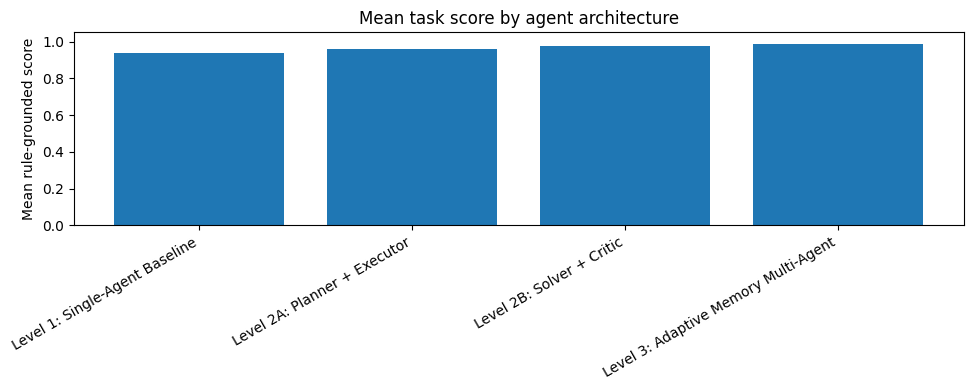

In [16]:
plot_df = results_df.groupby("architecture", as_index=False)["score"].mean()
plt.figure(figsize=(10,4))
plt.bar(plot_df["architecture"], plot_df["score"])
plt.ylim(0, 1.05); plt.ylabel("Mean rule-grounded score"); plt.title("Mean task score by agent architecture")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

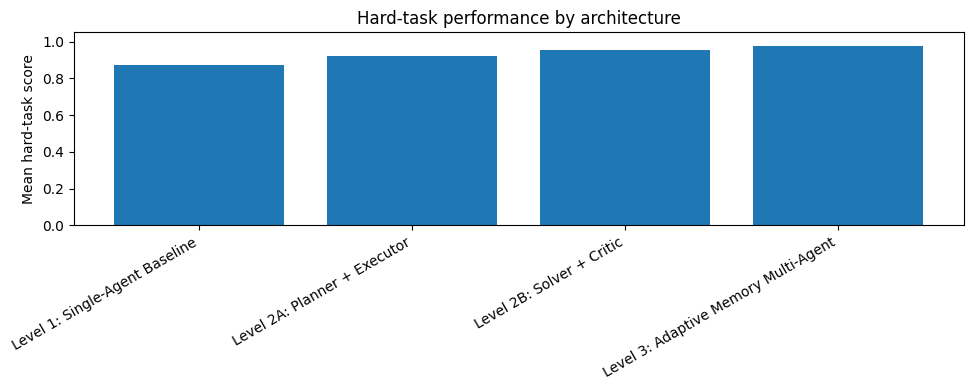

In [17]:
hard_df = results_df[results_df["difficulty"] == "hard"].groupby("architecture", as_index=False)["score"].mean()
plt.figure(figsize=(10,4))
plt.bar(hard_df["architecture"], hard_df["score"])
plt.ylim(0, 1.05); plt.ylabel("Mean hard-task score"); plt.title("Hard-task performance by architecture")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

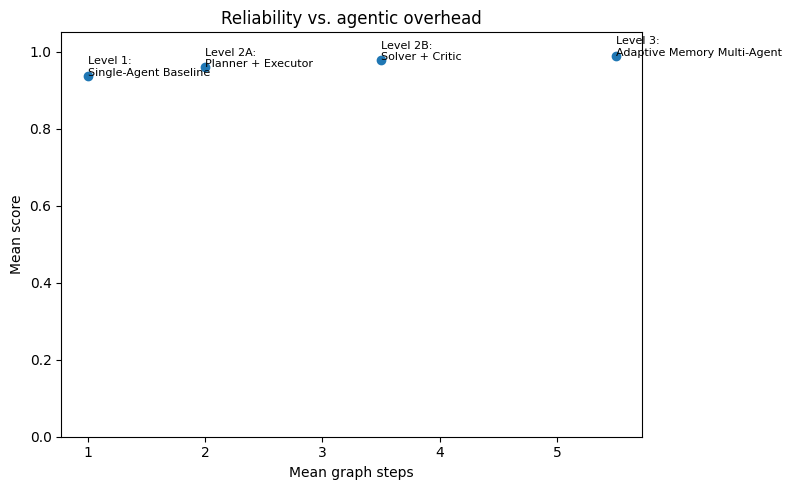

In [18]:
eff_plot = efficiency.sort_values("mean_steps")
plt.figure(figsize=(8,5))
plt.scatter(eff_plot["mean_steps"], eff_plot["mean_score"])
for _, row in eff_plot.iterrows():
    plt.annotate(row["architecture"].replace(": ", ":\n"), (row["mean_steps"], row["mean_score"]), fontsize=8)
plt.xlabel("Mean graph steps"); plt.ylabel("Mean score"); plt.ylim(0, 1.05); plt.title("Reliability vs. agentic overhead")
plt.tight_layout(); plt.show()

In [19]:
for task in TASKS:
    key = (1, "level3_adaptive_memory", task.task_id)
    state = artifacts[key]
    print("\n==", task.task_id, "==")
    print("Score:", validate_result(task, state["result"])["score"])
    display(format_candidates(state["result"]))
    if state["result"].get("structures"):
        display(pd.DataFrame(state["result"]["structures"]))


== materials_easy_batio3 ==
Score: 1.0


,material_id,formula,dimension,band_gap,energy_above_hull,has_3d_pair,ranking_score,elements
0,mp-iof,BaTiO3,None,2.2934,0.0,None,None,"Ba, O, Ti"



== materials_hard_dimensional_polymorphs ==
Score: 0.9090909090909091


,material_id,formula,dimension,band_gap,energy_above_hull,has_3d_pair,ranking_score,elements
0,mp-iq,WS2,2D,1.5657,0.0,False,0.8397,"S, W"


,material_id,formula_pretty,dimension,structure_summary
0,mp-iq,WS2,2D,Structure and Robocrystallographer description...



== chem_easy_aspirin ==
Score: 1.0


,id,name,formula,molecular_weight,alogp_or_xlogp,hbd,hba,smiles,primary_median_pchembl,strongest_offtarget_pchembl,selectivity_margin,ranking_score
0,2244,aspirin,C9H8O4,180.16,1.2,1,4,CC(=O)OC1=CC=CC=C1C(=O)O,None,None,None,None



== chem_hard_selective_egfr_screen ==
Score: 1.0


,id,name,formula,molecular_weight,alogp_or_xlogp,hbd,hba,smiles,primary_median_pchembl,strongest_offtarget_pchembl,selectivity_margin,ranking_score
0,CHEMBL29197,NaN,C16H14BrN3O2,360.21,4.15,1,5,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC,10.60,5.83,4.77,5.130
1,CHEMBL3623290,AZD-3759,C22H23ClFN5O3,459.91,4.31,1,7,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1OC(=O)N1CCN(C)...,9.70,6.81,2.89,3.160
2,CHEMBL5957231,NaN,C31H31F3N6O4,608.62,4.32,3,7,CCN1CCN(Cc2ccc(C(=O)N[C@@H]3[C@H]4Oc5ccc(Oc6cc...,10.07,7.77,2.30,2.607


,molecule_chembl_id,pref_name,canonical_smiles,structure_summary
0,CHEMBL29197,NaN,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC,Canonical SMILES available through ChEMBL
1,CHEMBL3623290,AZD-3759,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1OC(=O)N1CCN(C)...,Canonical SMILES available through ChEMBL
2,CHEMBL5957231,NaN,CCN1CCN(Cc2ccc(C(=O)N[C@@H]3[C@H]4Oc5ccc(Oc6cc...,Canonical SMILES available through ChEMBL


## Failure Analysis

Hard tasks use partial-credit rubrics, so a score below 1.0 indicates missing evidence or constraint violations rather than a runtime failure. Common failure modes include insufficient chemical-system coverage, missing same-formula 3D polymorph evidence, incomplete Robocrystallographer joins, and non-selective or under-measured ChEMBL candidates.


In [20]:
failure_rows = []
for key, state in artifacts.items():
    run_id, arch_id, task_id = key
    task = next(t for t in TASKS if t.task_id == task_id)
    critique = validate_result(task, state["result"])
    for check in critique["checks"]:
        if not check["passed"]:
            failure_rows.append({"run_id":run_id, "architecture":ARCHITECTURES[arch_id], "task_id":task_id, "domain":task.domain, "difficulty":task.difficulty, "failed_check":check["check"]})
failure_df = pd.DataFrame(failure_rows)
failure_df if len(failure_df) else pd.DataFrame([{"message":"No failed checks in this run."}])

,run_id,architecture,task_id,domain,difficulty,failed_check
0,1,Level 1: Single-Agent Baseline,materials_hard_dimensional_polymorphs,materials,hard,same_formula_3d_polymorph_found
1,1,Level 1: Single-Agent Baseline,materials_hard_dimensional_polymorphs,materials,hard,structures_retrieved
2,1,Level 1: Single-Agent Baseline,chem_hard_selective_egfr_screen,cheminformatics,hard,returned_three_candidates
3,1,Level 2A: Planner + Executor,materials_hard_dimensional_polymorphs,materials,hard,structures_retrieved
4,1,Level 2A: Planner + Executor,chem_hard_selective_egfr_screen,cheminformatics,hard,returned_three_candidates
5,1,Level 2B: Solver + Critic,materials_hard_dimensional_polymorphs,materials,hard,same_formula_3d_polymorph_found
6,1,Level 3: Adaptive Memory Multi-Agent,materials_hard_dimensional_polymorphs,materials,hard,same_formula_3d_polymorph_found
7,2,Level 1: Single-Agent Baseline,materials_hard_dimensional_polymorphs,materials,hard,same_formula_3d_polymorph_found
8,2,Level 1: Single-Agent Baseline,materials_hard_dimensional_polymorphs,materials,hard,structures_retrieved
9,2,Level 1: Single-Agent Baseline,chem_hard_selective_egfr_screen,cheminformatics,hard,returned_three_candidates


## Conclusions

Easy tasks test direct property retrieval, while hard tasks require multi-hop retrieval, evidence aggregation, ranking, and rejected-candidate explanations. The central comparison is whether additional agent calls in Level 2 and Level 3 improve hard-task scores enough to justify increased runtime, step count, and token usage.


In [21]:
results_df.to_csv("agentic_architecture_results_raw.csv", index=False)
summary.to_csv("agentic_architecture_results_summary.csv", index=False)
matrix.to_csv("agentic_architecture_score_matrix.csv")
efficiency.to_csv("agentic_architecture_efficiency.csv", index=False)
print("Saved CSV outputs in the current working directory.")

Saved CSV outputs in the current working directory.
